In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadr import read_r
import numpy as np

# Load the data
ling_data = pd.read_csv('../data/lingData.txt', sep='\\s+')
ling_location = pd.read_csv('../data/lingLocation.txt', sep='\\s+')

# ling_data has a column for each question, and ling_location has a column
# for each question x answer.  Sorry the columns in ling_location are not usefully named,
# but it's not too tricky to figure out which is which.
# Note that you still need to clean this data (check for NA's, missing location data, etc.)

# Load the question_data which contains quest.mat, quest.use, ans.---
question_data = read_r('../data/question_data.RData')

In [2]:
# Inspect column names
print(ling_data.columns)
print(ling_location.columns)

# Load state geometries
state_df = gpd.read_file('../data/shapefiles')
state_df = state_df[state_df['iso_a2'] == 'US']  # Filter to only US

Index(['ID', 'CITY', 'STATE', 'ZIP', 'Q050', 'Q051', 'Q052', 'Q053', 'Q054',
       'Q055', 'Q056', 'Q057', 'Q058', 'Q059', 'Q060', 'Q061', 'Q062', 'Q063',
       'Q064', 'Q065', 'Q066', 'Q067', 'Q068', 'Q069', 'Q070', 'Q071', 'Q072',
       'Q073', 'Q074', 'Q075', 'Q076', 'Q077', 'Q078', 'Q079', 'Q080', 'Q081',
       'Q082', 'Q083', 'Q084', 'Q085', 'Q086', 'Q087', 'Q088', 'Q089', 'Q090',
       'Q091', 'Q092', 'Q093', 'Q094', 'Q095', 'Q096', 'Q097', 'Q098', 'Q099',
       'Q100', 'Q101', 'Q102', 'Q103', 'Q104', 'Q105', 'Q106', 'Q107', 'Q109',
       'Q110', 'Q111', 'Q115', 'Q117', 'Q118', 'Q119', 'Q120', 'Q121', 'lat',
       'long'],
      dtype='str')
Index(['Number of people in cell', 'Latitude', 'Longitude', 'V4', 'V5', 'V6',
       'V7', 'V8', 'V9', 'V10',
       ...
       'V462', 'V463', 'V464', 'V465', 'V466', 'V467', 'V468', 'V469', 'V470',
       'V471'],
      dtype='str', length=471)


/opt/miniconda3/envs/stat215a/lib/python3.14/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'shapefiles': 'ne_110m_admin_1_states_provinces 2' (default), 'ne_110m_admin_1_states_provinces'. Specify layer parameter to avoid this warning.
  result = read_func(


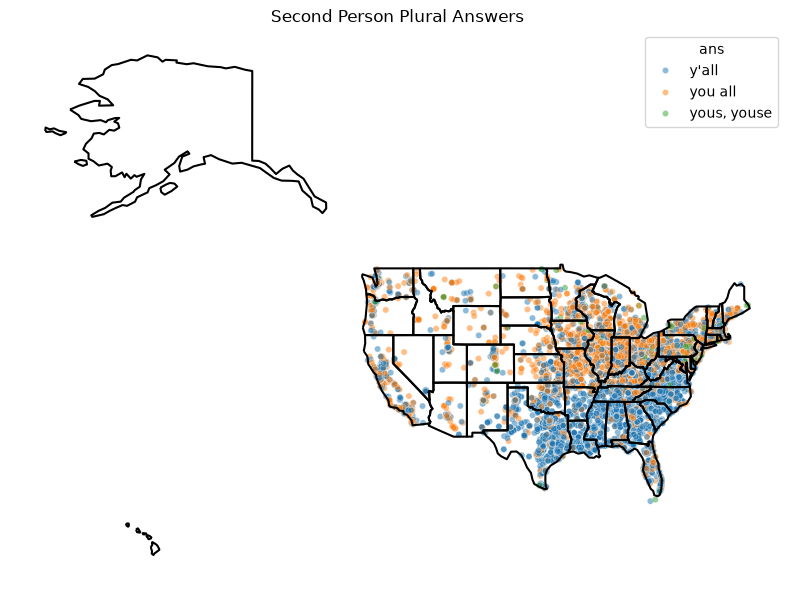

In [3]:
# Define the map theme
def my_map_theme():
    plt.axis('off')
# Note: the below plots are *ugly*. You can make nicer plots!

############
# Plot for the second person plural answers
plural_second_person = ling_data[(ling_data['Q050'].isin([1, 2, 9])) & (ling_data['long'] > -125)]
answers_q50 = question_data['ans.50']

# Prepare to join
answers_q50['Q050'] = (answers_q50.index + 1).astype(str)
plural_second_person['Q050'] = plural_second_person['Q050'].astype(str)
plural_second_person = plural_second_person.merge(answers_q50, on='Q050', how='inner')
# remove unused categories
plural_second_person['ans'] = plural_second_person['ans'].cat.remove_unused_categories()

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=plural_second_person, x='long', y='lat', hue='ans', s=20, alpha=0.5)
state_gdf = gpd.GeoDataFrame(state_df)
state_gdf.boundary.plot(ax=plt.gca(), color='black')
my_map_theme()
plt.title("Second Person Plural Answers")
plt.show()

/opt/miniconda3/envs/stat215a/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


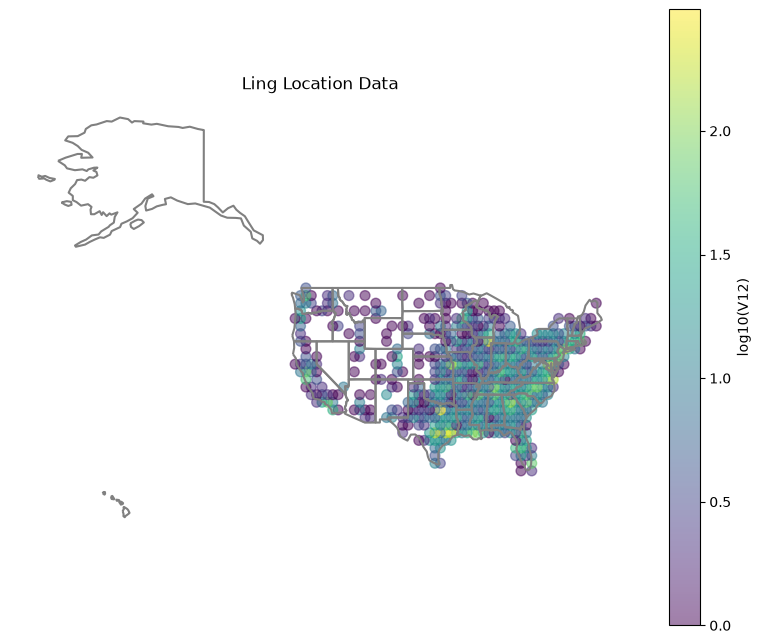

In [4]:

###############
# Plot the ling_location data
ling_location_filtered = ling_location[ling_location['Longitude'] > -125]

plt.figure(figsize=(10, 8))
plt.scatter(ling_location_filtered['Longitude'],
            ling_location_filtered['Latitude'],
            c=np.log10(ling_location_filtered['V12']),
            cmap='viridis', s=50, alpha=0.5)
state_gdf.boundary.plot(ax=plt.gca(), color='gray')
my_map_theme()
plt.colorbar(label='log10(V12)')
plt.title("Ling Location Data")
plt.show()

# Note: For county-level plots, you would typically need a shapefile for counties and join the data accordingly.

In [5]:
type(question_data)

collections.OrderedDict

In [6]:
question_data.keys()

odict_keys(['ans.1', 'ans.10', 'ans.100', 'ans.101', 'ans.102', 'ans.103', 'ans.104', 'ans.105', 'ans.106', 'ans.107', 'ans.108', 'ans.109', 'ans.11', 'ans.110', 'ans.111', 'ans.112', 'ans.113', 'ans.114', 'ans.115', 'ans.116', 'ans.117', 'ans.118', 'ans.119', 'ans.12', 'ans.120', 'ans.121', 'ans.122', 'ans.13', 'ans.14', 'ans.15', 'ans.16', 'ans.17', 'ans.18', 'ans.19', 'ans.2', 'ans.20', 'ans.21', 'ans.22', 'ans.23', 'ans.24', 'ans.25', 'ans.26', 'ans.27', 'ans.28', 'ans.29', 'ans.3', 'ans.30', 'ans.31', 'ans.32', 'ans.33', 'ans.34', 'ans.35', 'ans.36', 'ans.37', 'ans.38', 'ans.39', 'ans.4', 'ans.40', 'ans.41', 'ans.42', 'ans.43', 'ans.44', 'ans.45', 'ans.46', 'ans.47', 'ans.48', 'ans.49', 'ans.5', 'ans.50', 'ans.51', 'ans.52', 'ans.53', 'ans.54', 'ans.55', 'ans.56', 'ans.57', 'ans.58', 'ans.59', 'ans.6', 'ans.60', 'ans.61', 'ans.62', 'ans.63', 'ans.64', 'ans.65', 'ans.66', 'ans.67', 'ans.68', 'ans.69', 'ans.7', 'ans.70', 'ans.71', 'ans.72', 'ans.73', 'ans.74', 'ans.75', 'ans.76', 'a

In [7]:
print(type(question_data['quest.mat']))
print(question_data['quest.mat'].shape)
question_data['quest.mat'].head()

<class 'pandas.DataFrame'>
(122, 2)


,qnum,quest
0,1.0,<u><i>au</u></i>nt
1,2.0,b<u><i>ee</u></i>n
2,3.0,the first vowel in 'B<u><i>o</u></i>wie knife'
3,4.0,caramel
4,5.0,the vowel in the second syllable of 'caul<u><i...


In [8]:
questions_50_121 = question_data['quest.mat'][
    question_data['quest.mat']['qnum'].between(50, 121)
].copy()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

questions_50_121

,qnum,quest
49,50.0,What word(s) do you use to address a group of two or more people?
50,51.0,"Would you say 'Are you coming with?' as a full sentence, to mean 'Are you coming with us?'"
51,52.0,Would you say 'where are you at?' to mean 'where are you?'
52,53.0,"Modals are words like 'can,' 'could,' 'might,' 'ought to,' and so on. Can you use more than one modal at a time? (e.g., 'I might could do that' to mean 'I might be able to do that'; or 'I used to could do that' to mean 'I used to be able to do that')"
53,54.0,"He used to nap on the couch, but he sprawls out in that new lounge chair anymore"
54,55.0,I do exclusively figurative paintings anymore
55,56.0,Pantyhose are so expensive anymore that I just try to get a good suntan and forget about it.
56,57.0,Forget the nice clothes anymore (referring to babies eating messily after a certain age)
57,58.0,"Which of these terms do you prefer for a sale of unwanted items on your porch, in your yard, etc.?"
58,59.0,"What do you call the game wherein the participants see who can throw a knife closest to the other person (or alternately, get a jackknife to stick into the ground or a piece of wood)?"


In [9]:
ling_data.columns.tolist()

['ID',
 'CITY',
 'STATE',
 'ZIP',
 'Q050',
 'Q051',
 'Q052',
 'Q053',
 'Q054',
 'Q055',
 'Q056',
 'Q057',
 'Q058',
 'Q059',
 'Q060',
 'Q061',
 'Q062',
 'Q063',
 'Q064',
 'Q065',
 'Q066',
 'Q067',
 'Q068',
 'Q069',
 'Q070',
 'Q071',
 'Q072',
 'Q073',
 'Q074',
 'Q075',
 'Q076',
 'Q077',
 'Q078',
 'Q079',
 'Q080',
 'Q081',
 'Q082',
 'Q083',
 'Q084',
 'Q085',
 'Q086',
 'Q087',
 'Q088',
 'Q089',
 'Q090',
 'Q091',
 'Q092',
 'Q093',
 'Q094',
 'Q095',
 'Q096',
 'Q097',
 'Q098',
 'Q099',
 'Q100',
 'Q101',
 'Q102',
 'Q103',
 'Q104',
 'Q105',
 'Q106',
 'Q107',
 'Q109',
 'Q110',
 'Q111',
 'Q115',
 'Q117',
 'Q118',
 'Q119',
 'Q120',
 'Q121',
 'lat',
 'long']

How do the terms Americans use for their maternal and paternal grandmothers vary geographically, and are the geographic patterns similar or different between the two sides of the family?

(Do respondents tend to use the same term for their maternal and paternal grandmothers, and does this pattern vary geographically?)

q.68: What nicknames do/did you use for your maternal grandmother?
q.69: What about your paternal grandmother (is there a distinction?)

In [10]:
question_data['ans.68']

,qnum,ans.let,per,ans
0,68,a,4.78,grandmother
1,68,b,3.77,granny
2,68,c,50.67,grandma
3,68,d,5.77,nana
4,68,e,0.97,mimi
5,68,f,3.24,grammy/grammie/grammi
6,68,g,30.79,other


In [11]:
question_data['ans.69']

,qnum,ans.let,per,ans
0,69,a,6.38,grandmother
1,69,b,3.67,granny
2,69,c,47.70,grandma
3,69,d,13.67,gramma
4,69,e,4.49,nana
5,69,f,24.09,other


In [12]:
q68 = ling_data[['ID', 'CITY', 'STATE', 'ZIP', 'Q068', 'lat', 'long']].copy()
q69 = ling_data[['ID', 'CITY', 'STATE', 'ZIP', 'Q069', 'lat', 'long']].copy()

print(q68['Q068'].value_counts(dropna=False).sort_index())
print(q69['Q069'].value_counts(dropna=False).sort_index())

Q068
0     1693
1     2457
2     1632
3    23184
4     2491
5      388
6     1273
7    14353
Name: count, dtype: int64
Q069
0     2030
1     3029
2     1636
3    21466
4     6719
5     1790
6    10801
Name: count, dtype: int64


In [13]:
q68_labels = {
    1: 'grandmother',
    2: 'granny',
    3: 'grandma',
    4: 'nana',
    5: 'mimi',
    6: 'grammy/grammie/grammi',
    7: 'other'
}

q69_labels = {
    1: 'grandmother',
    2: 'granny',
    3: 'grandma',
    4: 'gramma',
    5: 'nana',
    6: 'other'
}

grandma_data = ling_data[
    (ling_data['Q068'] != 0) &
    (ling_data['Q069'] != 0)
].copy()

grandma_data['maternal_term'] = grandma_data['Q068'].map(q68_labels)
grandma_data['paternal_term'] = grandma_data['Q069'].map(q69_labels)

print("Number of respondents:", len(grandma_data))

grandma_data[
    ['Q068', 'maternal_term', 'Q069', 'paternal_term']
].head(10)

Number of respondents: 45216


,Q068,maternal_term,Q069,paternal_term
0,7,other,4,gramma
1,3,grandma,3,grandma
2,7,other,6,other
3,7,other,6,other
4,7,other,6,other
5,7,other,6,other
6,4,nana,5,nana
7,7,other,6,other
8,3,grandma,3,grandma
9,4,nana,6,other


do people use same term for both maternal and paternal side?

In [14]:
pd.crosstab(
    grandma_data['maternal_term'],
    grandma_data['paternal_term'],
    normalize='index'
).round(3)

paternal_term,gramma,grandma,grandmother,granny,nana,other
maternal_term,,,,,,
grammy/grammie/grammi,0.167,0.312,0.051,0.023,0.092,0.354
grandma,0.084,0.724,0.026,0.025,0.025,0.116
grandmother,0.039,0.141,0.615,0.037,0.030,0.138
granny,0.079,0.326,0.061,0.260,0.032,0.243
mimi,0.113,0.300,0.074,0.063,0.116,0.334
nana,0.120,0.390,0.055,0.025,0.177,0.232
other,0.281,0.172,0.041,0.030,0.034,0.442


In [15]:
grandma_data['same_term'] = (
    grandma_data['maternal_term'] == grandma_data['paternal_term']
)

grandma_data['same_term'].value_counts(normalize=True)

same_term
True     0.5579
False    0.4421
Name: proportion, dtype: float64

55% of respondents are using same terms for both sides. 

Knowing the term used for a maternal grandmother appears to provide information about the term used for a paternal grandmother, but the strength of this relationship varies substantially across terms.

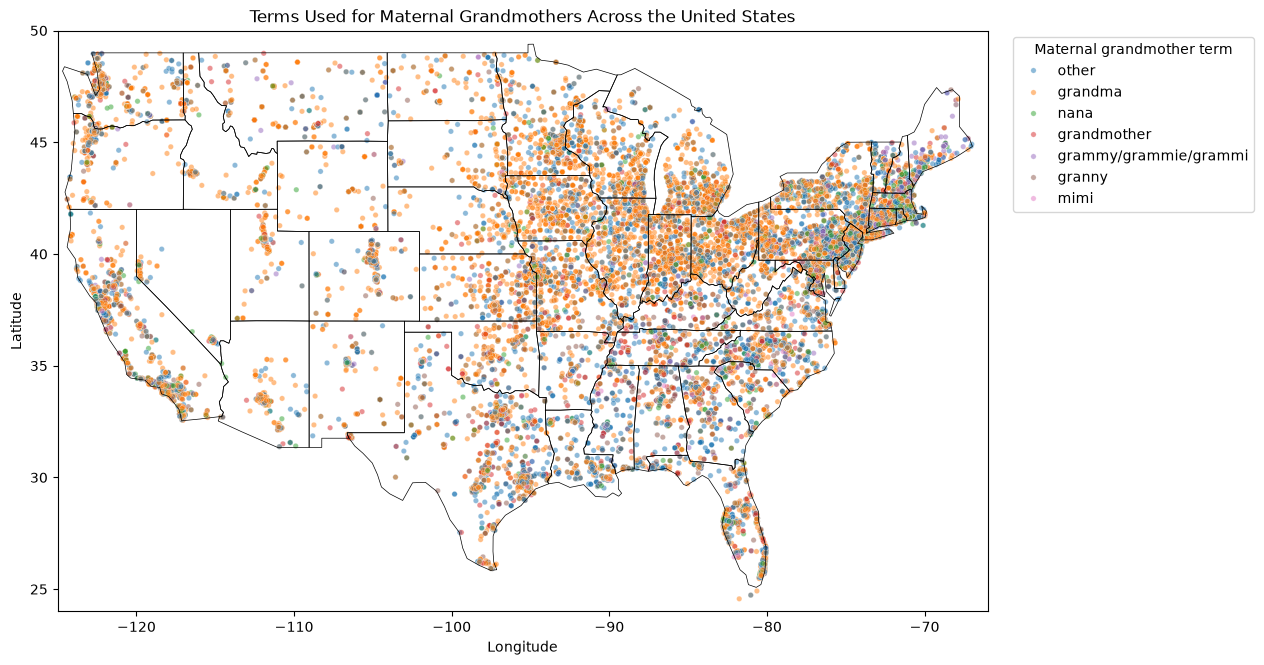

In [16]:
q68_map = grandma_data[
    grandma_data['long'].notna() &
    grandma_data['lat'].notna()
].copy()

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=q68_map,
    x='long',
    y='lat',
    hue='maternal_term',
    s=15,
    alpha=0.5
)

state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black',
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.title("Terms Used for Maternal Grandmothers Across the United States")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Maternal grandmother term",
           bbox_to_anchor=(1.02, 1),
           loc='upper left')
plt.savefig(
    "../report/q68_maternal_grandmother_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

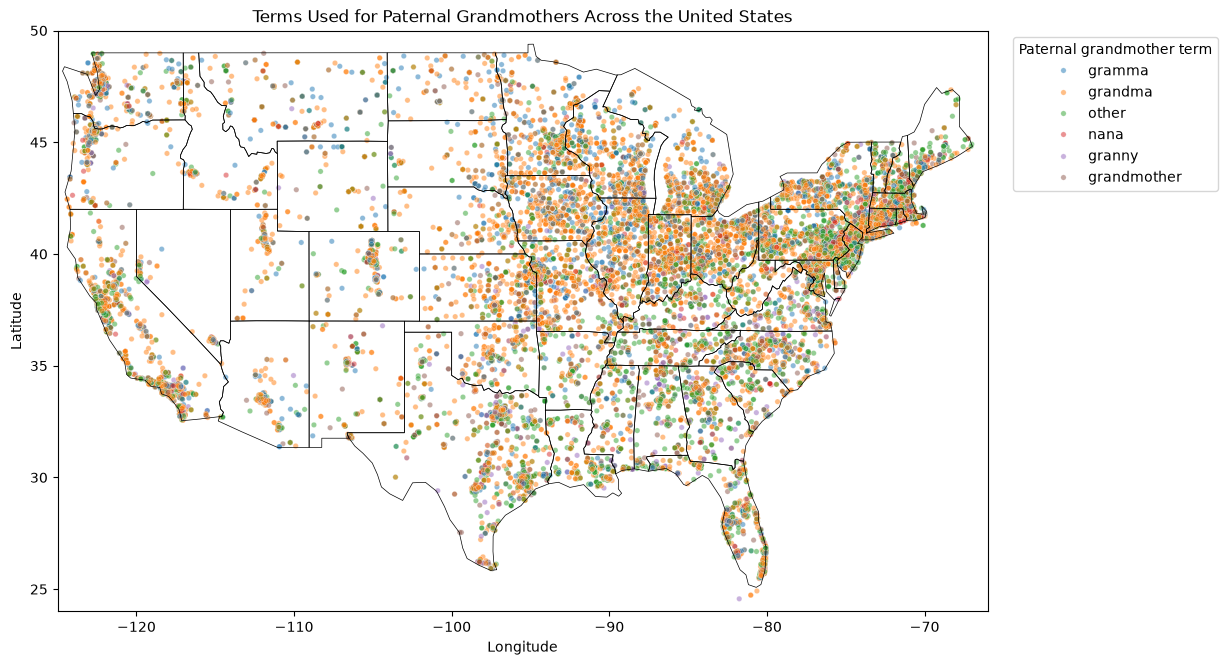

In [17]:
q69_map = grandma_data[
    grandma_data['long'].notna() &
    grandma_data['lat'].notna()
].copy()

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=q69_map,
    x='long',
    y='lat',
    hue='paternal_term',
    s=15,
    alpha=0.5
)

state_gdf.boundary.plot(
    ax=plt.gca(),
    color='black',
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.title("Terms Used for Paternal Grandmothers Across the United States")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(
    title="Paternal grandmother term",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.savefig(
    "../report/q69_paternal_grandmother_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

does it differ by states?

In [18]:
maternal_state = pd.crosstab(
    grandma_data['STATE'],
    grandma_data['maternal_term'],
    normalize='index'
)

maternal_state.head(10)

maternal_term,grammy/grammie/grammi,grandma,grandmother,granny,mimi,nana,other
STATE,,,,,,,
!L,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
94,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
AB,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AK,0.043478,0.543478,0.054348,0.021739,0.010870,0.054348,0.271739
AL,0.010178,0.335878,0.139949,0.119593,0.010178,0.038168,0.346056
AR,0.009615,0.375000,0.091346,0.072115,0.019231,0.028846,0.403846
AZ,0.017045,0.573864,0.036932,0.017045,0.000000,0.048295,0.306818
BC,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [19]:
paternal_state = pd.crosstab(
    grandma_data['STATE'],
    grandma_data['paternal_term'],
    normalize='index'
)

paternal_state.head(10)

paternal_term,gramma,grandma,grandmother,granny,nana,other
STATE,,,,,,
!L,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
94,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
AB,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
AK,0.206522,0.489130,0.054348,0.032609,0.021739,0.195652
AL,0.066158,0.333333,0.142494,0.101781,0.022901,0.333333
AR,0.105769,0.375000,0.125000,0.067308,0.019231,0.307692
AZ,0.210227,0.500000,0.065341,0.025568,0.025568,0.173295
BC,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


remove non-us states

In [20]:
us_states = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
    'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD',
    'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
    'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY','DC'
]

grandma_us = grandma_data[
    grandma_data['STATE'].isin(us_states)
].copy()

print("Before:", len(grandma_data))
print("After keeping U.S. states + DC:", len(grandma_us))

Before: 45216
After keeping U.S. states + DC: 45071


In [21]:
maternal_state = pd.crosstab(
    grandma_us['STATE'],
    grandma_us['maternal_term'],
    normalize='index'
)

paternal_state = pd.crosstab(
    grandma_us['STATE'],
    grandma_us['paternal_term'],
    normalize='index'
)

In [22]:
for term in ['grandma', 'grandmother', 'granny', 'nana']:
    print("\n", term.upper())
    print(
        maternal_state[term]
        .sort_values(ascending=False)
        .head(10)
        .round(3)
    )


 GRANDMA
STATE
SD    0.680
UT    0.670
WY    0.663
ID    0.645
IA    0.634
KS    0.630
NE    0.627
WI    0.617
ND    0.614
HI    0.600
Name: grandma, dtype: float64

 GRANDMOTHER
STATE
AL    0.140
DC    0.114
MS    0.108
TN    0.103
KY    0.103
OK    0.098
DE    0.093
AR    0.091
GA    0.090
NV    0.083
Name: grandmother, dtype: float64

 GRANNY
STATE
TN    0.125
AL    0.120
KY    0.109
SC    0.083
GA    0.073
AR    0.072
MS    0.070
TX    0.067
NC    0.063
LA    0.062
Name: granny, dtype: float64

 NANA
STATE
RI    0.186
MA    0.144
NH    0.125
ME    0.112
NJ    0.091
HI    0.090
CT    0.086
NV    0.083
PA    0.079
SC    0.076
Name: nana, dtype: float64


The terms used for maternal grandmothers show clear geographic variation. “Granny” is relatively more common in Southern states, whereas “nana” is particularly common in the Northeast, especially New England.

<Figure size 1400x600 with 0 Axes>

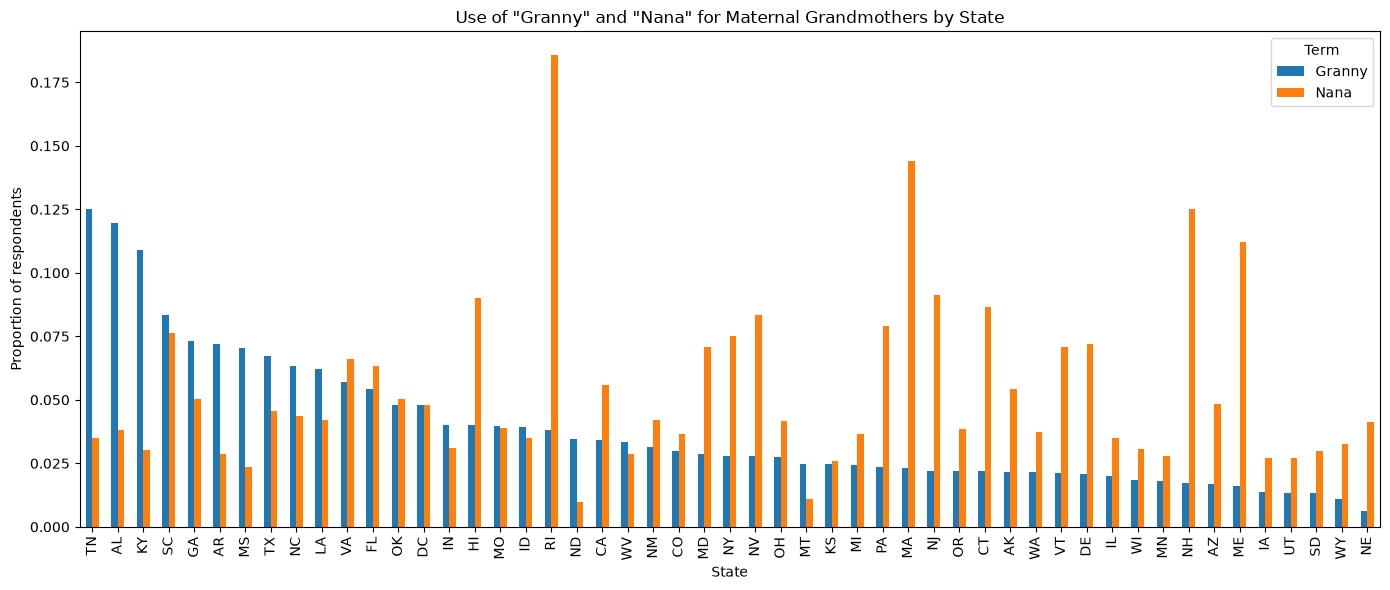

In [23]:
compare_terms = pd.DataFrame({
    'Granny': maternal_state['granny'],
    'Nana': maternal_state['nana']
})

compare_terms = compare_terms.sort_values('Granny', ascending=False)

plt.figure(figsize=(14, 6))

compare_terms.plot(
    kind='bar',
    figsize=(14, 6)
)

plt.ylabel('Proportion of respondents')
plt.xlabel('State')
plt.title('Use of "Granny" and "Nana" for Maternal Grandmothers by State')
plt.legend(title='Term')
plt.tight_layout()
plt.show()

In [24]:
for term in ['grandma', 'grandmother', 'granny', 'nana']:
    print("\n", term.upper())
    print(
        paternal_state[term]
        .sort_values(ascending=False)
        .head(10)
        .round(3)
    )


 GRANDMA
STATE
UT    0.603
ID    0.601
KS    0.575
ND    0.574
NE    0.573
MO    0.570
IA    0.566
HI    0.550
SD    0.548
MN    0.545
Name: grandma, dtype: float64

 GRANDMOTHER
STATE
DC    0.156
DE    0.144
AL    0.142
MS    0.131
NV    0.130
AR    0.125
TN    0.125
NC    0.116
GA    0.111
ME    0.102
Name: grandmother, dtype: float64

 GRANNY
STATE
KY    0.113
TN    0.103
AL    0.102
GA    0.093
SC    0.087
NC    0.080
MS    0.080
LA    0.074
DC    0.072
OK    0.071
Name: granny, dtype: float64

 NANA
STATE
MA    0.134
RI    0.126
ME    0.118
NH    0.091
NJ    0.075
CT    0.068
PA    0.062
DE    0.062
NM    0.052
MD    0.052
Name: nana, dtype: float64


for granny

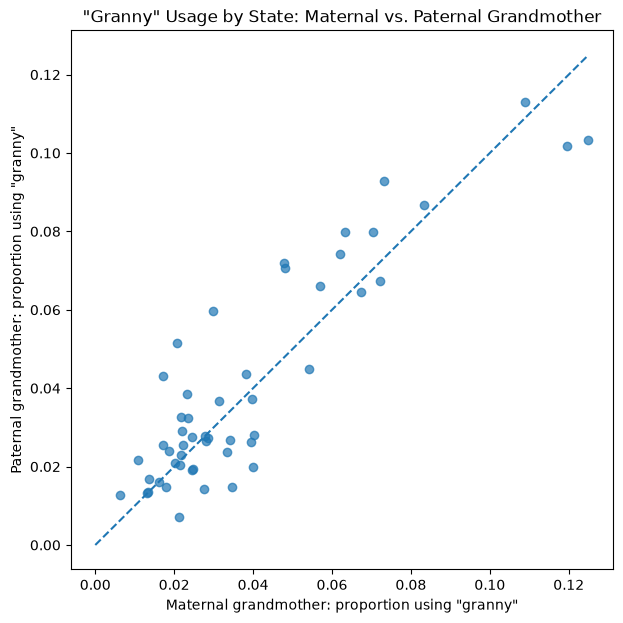

In [25]:
granny_compare = pd.DataFrame({
    'maternal': maternal_state['granny'],
    'paternal': paternal_state['granny']
}).dropna()

plt.figure(figsize=(7, 7))

plt.scatter(
    granny_compare['maternal'],
    granny_compare['paternal'],
    alpha=0.7
)

max_val = max(
    granny_compare['maternal'].max(),
    granny_compare['paternal'].max()
)

plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel('Maternal grandmother: proportion using "granny"')
plt.ylabel('Paternal grandmother: proportion using "granny"')
plt.title('"Granny" Usage by State: Maternal vs. Paternal Grandmother')

plt.show()

for nana

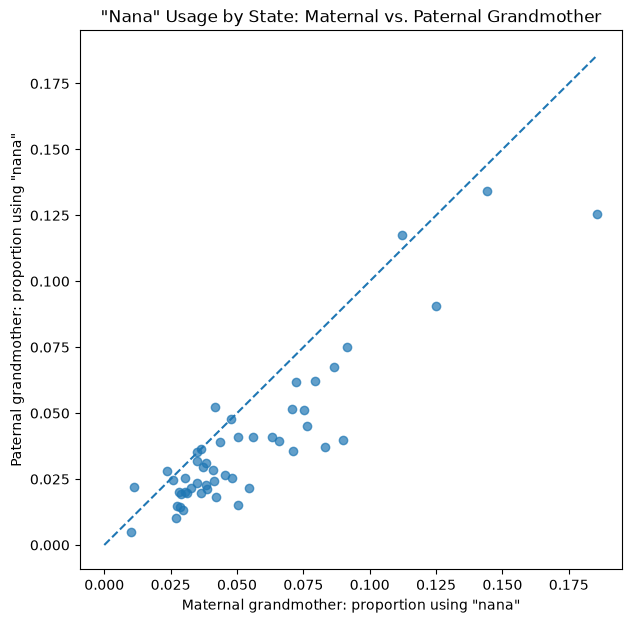

In [26]:
nana_compare = pd.DataFrame({
    'maternal': maternal_state['nana'],
    'paternal': paternal_state['nana']
}).dropna()

plt.figure(figsize=(7, 7))

plt.scatter(
    nana_compare['maternal'],
    nana_compare['paternal'],
    alpha=0.7
)

max_val = max(
    nana_compare['maternal'].max(),
    nana_compare['paternal'].max()
)

plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel('Maternal grandmother: proportion using "nana"')
plt.ylabel('Paternal grandmother: proportion using "nana"')
plt.title('"Nana" Usage by State: Maternal vs. Paternal Grandmother')

plt.show()

In [27]:
print(
    "Granny correlation:",
    granny_compare['maternal'].corr(granny_compare['paternal'])
)

print(
    "Nana correlation:",
    nana_compare['maternal'].corr(nana_compare['paternal'])
)

Granny correlation: 0.8966836845281403
Nana correlation: 0.9075691690390338


### Do the answers to the two questions define any distinct geographical groups?

Yes. The terms used for maternal and paternal grandmothers show clear geographic variation.

For example, the term **"granny"** is relatively more common in Southern and Southeastern states. For maternal grandmothers, states such as Tennessee, Alabama, Kentucky, South Carolina, Georgia, Arkansas, and Mississippi had relatively high proportions of "granny" responses. A very similar pattern appeared for paternal grandmothers.

In contrast, **"nana"** was relatively more common in the Northeast, especially in New England. States such as Rhode Island, Massachusetts, New Hampshire, Maine, New Jersey, and Connecticut had relatively high proportions of "nana" responses.

These patterns suggest that grandmother terms are not distributed randomly across the United States and that some lexical choices correspond to distinct geographic regions.

### Does a response to one question help predict the other?

Yes. Responses to the maternal-grandmother question are strongly related to responses to the paternal-grandmother question.

Among respondents who answered both questions, about **55.8%** selected the same response label for both maternal and paternal grandmothers.

The relationship is especially strong for some terms. For example, among respondents who called their maternal grandmother **"grandma," 72.4%** also called their paternal grandmother "grandma." Similarly, 61.5% of those who used **"grandmother"** for their maternal grandmother also used "grandmother" for their paternal grandmother.

The geographic patterns are also very similar across the two questions. Across states, the maternal and paternal usage rates had correlations of approximately **0.90 for "granny"** and **0.91 for "nana."** This suggests that knowing how a respondent refers to one grandmother provides substantial information about how they may refer to the other.

One limitation is that the response categories for the two questions are not perfectly identical, so the 55.8% same-response measure should be interpreted with some caution.

try to analyze the categorical data for more than 2 questions: + grandfathers!!

In [28]:
question_data['ans.70']

,qnum,ans.let,per,ans
0,70,a,1.02,gramps
1,70,b,21.05,grandpa
2,70,c,13.86,grampa
3,70,d,5.07,"grandad, granddad"
4,70,e,0.84,pap
5,70,f,25.90,I spell it 'grandpa' but pronounce it as 'grampa'
6,70,g,32.26,other (including if you use a different term to address him directly than you do when speaking about him to a third party)


In [29]:
question_data['ans.71']

,qnum,ans.let,per,ans
0,71,a,0.95,gramps
1,71,b,32.29,grandpa
2,71,c,28.87,grampa
3,71,d,0.59,pap
4,71,e,37.31,other


In [30]:
q70_labels = {
    1: 'gramps',
    2: 'grandpa',
    3: 'grampa',
    4: 'grandad/granddad',
    5: 'pap',
    6: 'grandpa pronounced grampa',
    7: 'other'
}

q71_labels = {
    1: 'gramps',
    2: 'grandpa',
    3: 'grampa',
    4: 'pap',
    5: 'other'
}

grandparent_data = ling_data[
    (ling_data['Q068'] != 0) &
    (ling_data['Q069'] != 0) &
    (ling_data['Q070'] != 0) &
    (ling_data['Q071'] != 0)
].copy()

grandparent_data['maternal_grandmother'] = grandparent_data['Q068'].map(q68_labels)
grandparent_data['paternal_grandmother'] = grandparent_data['Q069'].map(q69_labels)
grandparent_data['maternal_grandfather'] = grandparent_data['Q070'].map(q70_labels)
grandparent_data['paternal_grandfather'] = grandparent_data['Q071'].map(q71_labels)

print("Number of respondents:", len(grandparent_data))

grandparent_data[
    [
        'maternal_grandmother',
        'paternal_grandmother',
        'maternal_grandfather',
        'paternal_grandfather'
    ]
].head(10)

Number of respondents: 44276


,maternal_grandmother,paternal_grandmother,maternal_grandfather,paternal_grandfather
0,other,gramma,grandpa pronounced grampa,other
1,grandma,grandma,grandpa pronounced grampa,grandpa
2,other,other,other,other
3,other,other,other,other
5,other,other,other,other
6,nana,nana,other,other
7,other,other,other,other
8,grandma,grandma,grandpa pronounced grampa,other
9,nana,other,other,other
10,other,other,other,other


In [31]:
pd.crosstab(
    grandparent_data['maternal_grandfather'],
    grandparent_data['paternal_grandfather'],
    normalize='index'
).round(3)

paternal_grandfather,grampa,gramps,grandpa,other,pap
maternal_grandfather,,,,,
grampa,0.736,0.008,0.116,0.137,0.003
gramps,0.174,0.186,0.330,0.265,0.045
grandad/granddad,0.139,0.010,0.227,0.612,0.012
grandpa,0.035,0.007,0.801,0.154,0.004
grandpa pronounced grampa,0.494,0.008,0.259,0.238,0.002
other,0.131,0.009,0.181,0.673,0.006
pap,0.188,0.020,0.238,0.272,0.281


In [32]:
grandparent_data['same_grandfather_term'] = (
    grandparent_data['maternal_grandfather'] ==
    grandparent_data['paternal_grandfather']
)

grandparent_data['same_grandfather_term'].value_counts(normalize=True)

same_grandfather_term
False    0.506505
True     0.493495
Name: proportion, dtype: float64

In [33]:
grandparent_us = grandparent_data[
    grandparent_data['STATE'].isin(us_states)
].copy()

maternal_grandfather_state = pd.crosstab(
    grandparent_us['STATE'],
    grandparent_us['maternal_grandfather'],
    normalize='index'
)

paternal_grandfather_state = pd.crosstab(
    grandparent_us['STATE'],
    grandparent_us['paternal_grandfather'],
    normalize='index'
)

In [34]:
for term in ['grandpa', 'grampa', 'gramps', 'pap']:
    print("\n", term.upper())
    print(
        maternal_grandfather_state[term]
        .sort_values(ascending=False)
        .head(10)
        .round(3)
    )


 GRANDPA
STATE
MO    0.308
HI    0.303
ID    0.302
UT    0.299
IN    0.298
KS    0.293
OH    0.281
SD    0.279
NE    0.279
NV    0.278
Name: grandpa, dtype: float64

 GRAMPA
STATE
MT    0.228
WI    0.228
MN    0.222
WY    0.217
IA    0.212
MI    0.210
SD    0.209
ND    0.208
OR    0.183
VT    0.182
Name: grampa, dtype: float64

 GRAMPS
STATE
CO    0.040
ID    0.027
SD    0.023
ME    0.022
NH    0.022
WY    0.022
AR    0.020
RI    0.017
OR    0.017
WI    0.016
Name: gramps, dtype: float64

 PAP
STATE
PA    0.047
WV    0.043
AL    0.016
CO    0.015
AR    0.015
KY    0.012
MD    0.011
NM    0.011
FL    0.009
NJ    0.008
Name: pap, dtype: float64


In [35]:
for term in ['grandpa', 'grampa', 'gramps', 'pap']:
    print("\n", term.upper())
    print(
        paternal_grandfather_state[term]
        .sort_values(ascending=False)
        .head(10)
        .round(3)
    )


 GRANDPA
STATE
UT    0.439
ID    0.436
IN    0.428
NE    0.413
AK    0.411
MO    0.407
SD    0.402
KS    0.393
OH    0.387
AZ    0.383
Name: grandpa, dtype: float64

 GRAMPA
STATE
ND    0.490
SD    0.442
IA    0.438
WI    0.430
MN    0.412
MT    0.409
MI    0.409
OR    0.381
WA    0.373
AZ    0.372
Name: grampa, dtype: float64

 GRAMPS
STATE
SD    0.023
RI    0.023
ND    0.020
WI    0.019
DC    0.019
ME    0.017
NJ    0.016
MA    0.016
CO    0.015
KY    0.014
Name: gramps, dtype: float64

 PAP
STATE
PA    0.047
CO    0.035
WV    0.029
SC    0.018
AL    0.013
RI    0.011
ME    0.011
GA    0.011
VA    0.010
TN    0.009
Name: pap, dtype: float64


### Extending the analysis to grandfather terms

I extended the analysis to Q70 and Q71, which ask respondents what they call their maternal and paternal grandfathers!!

The grandfather terms also show geographic variation. In particular, "grampa" is relatively common in the Upper Midwest and northern states. For the maternal-grandfather question, Montana (22.8%), Wisconsin (22.8%), Minnesota (22.2%), Wyoming (21.7%), Iowa (21.2%), Michigan (21.0%), South Dakota (20.9%), and North Dakota (20.8%) had relatively high proportions of "grampa."

A similar and even stronger geographic pattern appears for paternal grandfathers. "Grampa" was especially common in North Dakota (49.0%), South Dakota (44.2%), Iowa (43.8%), Wisconsin (43.0%), Minnesota (41.2%), Montana (40.9%), and Michigan (40.9%).

The less common term "pap" also shows some geographic concentration. Pennsylvania had the highest proportion for both maternal and paternal grandfathers (4.7%), and West Virginia was also among the states with the highest usage. However, because "pap" is uncommon overall, this pattern should be interpreted cautiously.

Together with the grandmother results, these findings suggest that geographic variation in grandparent terminology is not limited to a single question. Similar regional structure appears across multiple kinship terms.

In [36]:
for term in ['grandpa', 'grampa', 'gramps', 'pap']:
    common_states = (
        maternal_grandfather_state[[term]]
        .join(
            paternal_grandfather_state[[term]],
            lsuffix='_maternal',
            rsuffix='_paternal',
            how='inner'
        )
    )

    correlation = common_states.iloc[:, 0].corr(common_states.iloc[:, 1])

    print(term, round(correlation, 3))

grandpa 0.879
grampa 0.898
gramps 0.323
pap 0.843


### Relationship between maternal and paternal grandfather terms

The geographic distributions of several grandfather terms were also similar between the maternal and paternal questions. Across states, the correlations between maternal and paternal usage rates were 0.879 for "grandpa," 0.898 for "grampa," and 0.843 for "pap." In contrast, the correlation for "gramps" was substantially weaker (0.323).

These results suggest that the geographic patterns are not specific to only one side of the family. For several common grandfather terms, states where a term is relatively common for maternal grandfathers also tend to be states where the same term is relatively common for paternal grandfathers.

In [37]:
grandparent_data['maternal_grandfather_harmonized'] = (
    grandparent_data['maternal_grandfather']
    .replace({
        'grandpa pronounced grampa': 'grampa',
        'grandad/granddad': 'other'
    })
)

grandparent_data['paternal_grandfather_harmonized'] = (
    grandparent_data['paternal_grandfather']
)

pd.crosstab(
    grandparent_data['maternal_grandfather_harmonized'],
    grandparent_data['paternal_grandfather_harmonized'],
    normalize='index'
).round(3)

paternal_grandfather_harmonized,grampa,gramps,grandpa,other,pap
maternal_grandfather_harmonized,,,,,
grampa,0.579,0.008,0.209,0.203,0.002
gramps,0.174,0.186,0.330,0.265,0.045
grandpa,0.035,0.007,0.801,0.154,0.004
other,0.132,0.009,0.188,0.664,0.007
pap,0.188,0.020,0.238,0.272,0.281


In [38]:
grandparent_data['same_grandfather_term_harmonized'] = (
    grandparent_data['maternal_grandfather_harmonized'] ==
    grandparent_data['paternal_grandfather_harmonized']
)

grandparent_data[
    'same_grandfather_term_harmonized'
].value_counts(normalize=True).round(3)

same_grandfather_term_harmonized
True     0.654
False    0.346
Name: proportion, dtype: float64

### Harmonizing the grandfather response categories

Because Q70 and Q71 did not use exactly the same response categories, I harmonized the categories before directly comparing maternal and paternal grandfather terms. In particular, Q70 separately included "grandpa pronounced grampa," while Q71 did not. I combined this category with "grampa" and grouped the Q70-specific "grandad/granddad" category into "other."

After harmonization, 65.4% of respondents used the same response category for their maternal and paternal grandfathers, compared with 49.3% before harmonization.

The relationship was particularly strong for "grandpa": among respondents who used "grandpa" for their maternal grandfather, 80.1% also used "grandpa" for their paternal grandfather. Among those who used "grampa" for their maternal grandfather, 57.9% also used "grampa" for their paternal grandfather.

This provides additional evidence that a respondent's terminology for one grandparent contains information about the terminology they use for another grandparent.

In [39]:
grandparent_us = grandparent_data[
    grandparent_data['STATE'].isin(us_states)
].copy()

questions = {
    'maternal_grandmother': 'MG',
    'paternal_grandmother': 'PG',
    'maternal_grandfather_harmonized': 'MF',
    'paternal_grandfather_harmonized': 'PF'
}

state_profiles = []

for variable, prefix in questions.items():
    table = pd.crosstab(
        grandparent_us['STATE'],
        grandparent_us[variable],
        normalize='index'
    )
    
    table.columns = [f'{prefix}_{col}' for col in table.columns]
    state_profiles.append(table)

state_profile = pd.concat(state_profiles, axis=1).fillna(0)

print(state_profile.shape)
state_profile.head()

(51, 23)


,MG_grammy/grammie/grammi,MG_grandma,MG_grandmother,MG_granny,MG_mimi,MG_nana,MG_other,PG_gramma,PG_grandma,PG_grandmother,...,MF_grampa,MF_gramps,MF_grandpa,MF_other,MF_pap,PF_grampa,PF_gramps,PF_grandpa,PF_other,PF_pap
STATE,,,,,,,,,,,,,,,,,,,,,
AK,0.044444,0.533333,0.055556,0.022222,0.011111,0.055556,0.277778,0.211111,0.488889,0.055556,...,0.500000,0.000000,0.233333,0.266667,0.000000,0.333333,0.011111,0.411111,0.244444,0.000000
AL,0.010499,0.330709,0.136483,0.120735,0.010499,0.039370,0.351706,0.065617,0.335958,0.141732,...,0.186352,0.010499,0.186352,0.601050,0.015748,0.146982,0.002625,0.280840,0.556430,0.013123
AR,0.009756,0.380488,0.087805,0.068293,0.019512,0.029268,0.404878,0.107317,0.380488,0.117073,...,0.243902,0.019512,0.190244,0.531707,0.014634,0.204878,0.000000,0.292683,0.497561,0.004878
AZ,0.017291,0.576369,0.037464,0.014409,0.000000,0.048991,0.305476,0.210375,0.504323,0.063401,...,0.461095,0.005764,0.256484,0.270893,0.005764,0.371758,0.008646,0.383285,0.236311,0.000000
CA,0.025065,0.519447,0.050994,0.033420,0.006914,0.056468,0.307692,0.140593,0.493518,0.069144,...,0.404206,0.008931,0.252665,0.329876,0.004322,0.283204,0.008931,0.367329,0.338519,0.002017


In [40]:
from sklearn.cluster import KMeans

# Try 4 geographic/linguistic groups
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

state_clusters = kmeans.fit_predict(state_profile)

state_cluster_df = pd.DataFrame({
    'STATE': state_profile.index,
    'cluster': state_clusters
})

for cluster in sorted(state_cluster_df['cluster'].unique()):
    states = state_cluster_df.loc[
        state_cluster_df['cluster'] == cluster,
        'STATE'
    ].tolist()
    
    print(f"Cluster {cluster}:")
    print(states)
    print()

Cluster 0:
['AL', 'AR', 'DC', 'DE', 'GA', 'KY', 'LA', 'MS', 'NC', 'SC', 'TN', 'TX']

Cluster 1:
['IA', 'ID', 'MI', 'MN', 'MT', 'ND', 'NE', 'OR', 'SD', 'UT', 'WA', 'WI', 'WY']

Cluster 2:
['CT', 'FL', 'MA', 'MD', 'ME', 'NH', 'NJ', 'PA', 'RI', 'VA', 'VT', 'WV']

Cluster 3:
['AK', 'AZ', 'CA', 'CO', 'HI', 'IL', 'IN', 'KS', 'MO', 'NM', 'NV', 'NY', 'OH', 'OK']



/var/folders/xf/dw89pgxx7bdgn31f0w5p10lc0000gn/T/ipykernel_2704/3126447410.py:10: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  cluster_map.plot(


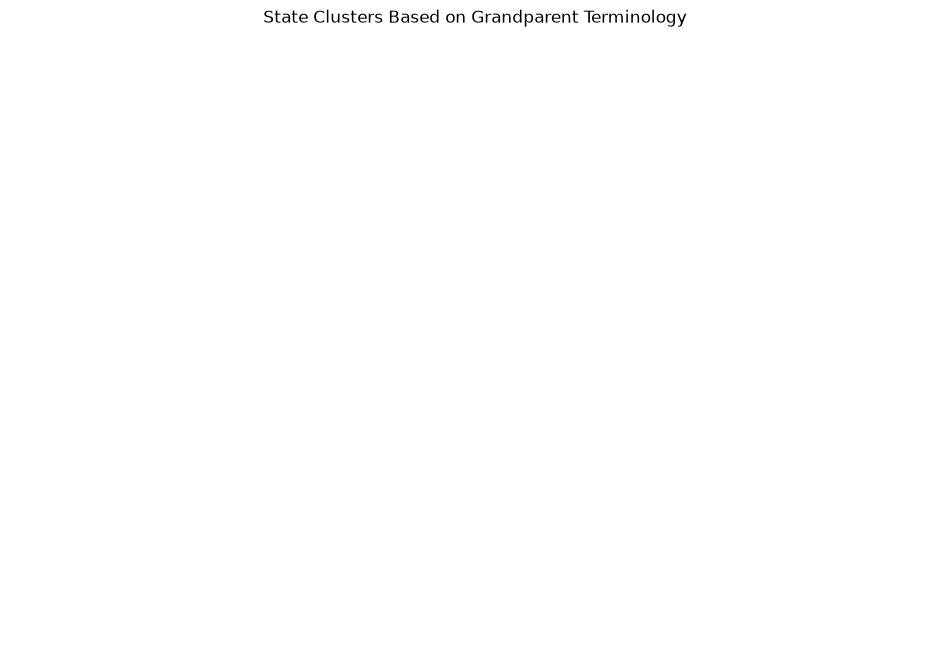

In [41]:
cluster_map = state_df.merge(
    state_cluster_df,
    left_on='iso_3166_2',
    right_on='STATE',
    how='inner'
)

fig, ax = plt.subplots(figsize=(12, 8))

cluster_map.plot(
    column='cluster',
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.set_title(
    'State Clusters Based on Grandparent Terminology'
)

ax.axis('off')

plt.show()

In [42]:
state_df['STATE'] = (
    state_df['iso_3166_2']
    .str.replace('US-', '', regex=False)
)

cluster_map = state_df.merge(
    state_cluster_df,
    on='STATE',
    how='inner'
)

print(cluster_map.shape)
print(cluster_map[['STATE', 'cluster']].head())

(51, 124)
  STATE  cluster
0    MN        1
1    MT        1
2    ND        1
3    HI        3
4    ID        1


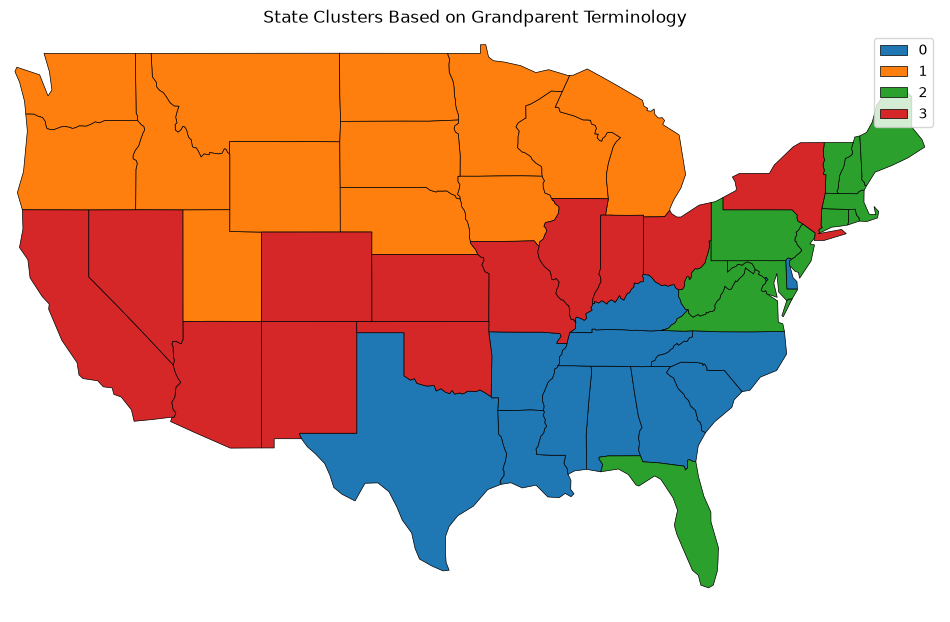

In [43]:
fig, ax = plt.subplots(figsize=(12, 8))

cluster_map.plot(
    column='cluster',
    categorical=True,
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    'State Clusters Based on Grandparent Terminology'
)

ax.axis('off')

plt.show()

### Geographic clustering of grandparent terminology

To examine whether the four grandparent terminology questions jointly define
distinct geographic groups, I represented each state by the proportions of
responses to the four questions (maternal grandmother, paternal grandmother,
maternal grandfather, and paternal grandfather) and applied K-means clustering
with four clusters. Geographic location was not included as an input to the
clustering algorithm.

Despite this, the resulting clusters show substantial geographic structure.
One cluster is concentrated in the South and Southeast, another covers much of
the northern and Upper Midwestern United States, and another is concentrated
in the Northeast and Mid-Atlantic. The fourth cluster is more geographically
mixed and includes much of the West and several Midwestern states.

This suggests that responses to the four grandparent terminology questions
jointly contain meaningful geographic information. However, the number of
clusters (k = 4) was chosen for this exploratory analysis, so the result should
not be interpreted as evidence that there are exactly four linguistic regions.

stability check for k=3, k=5

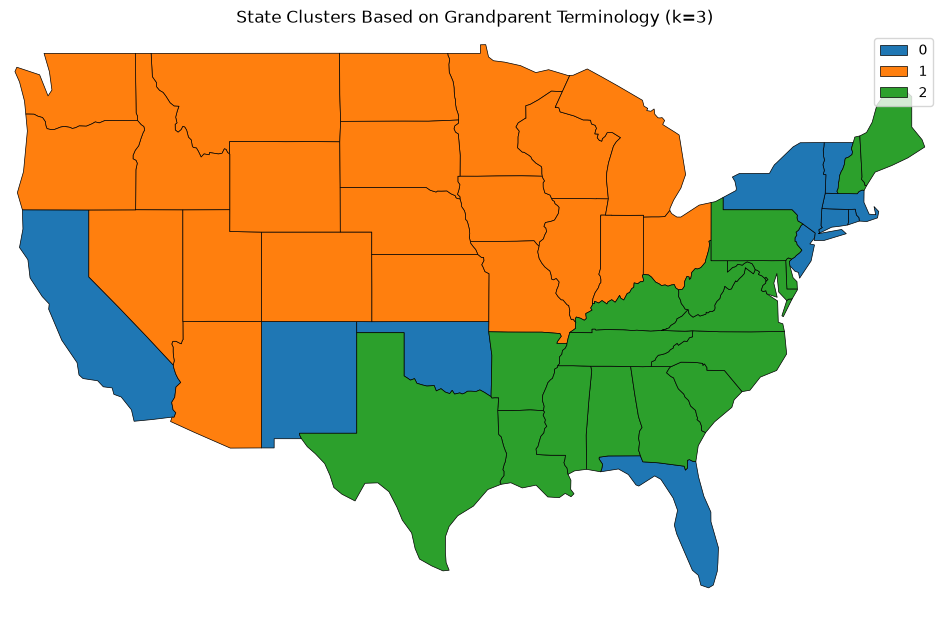

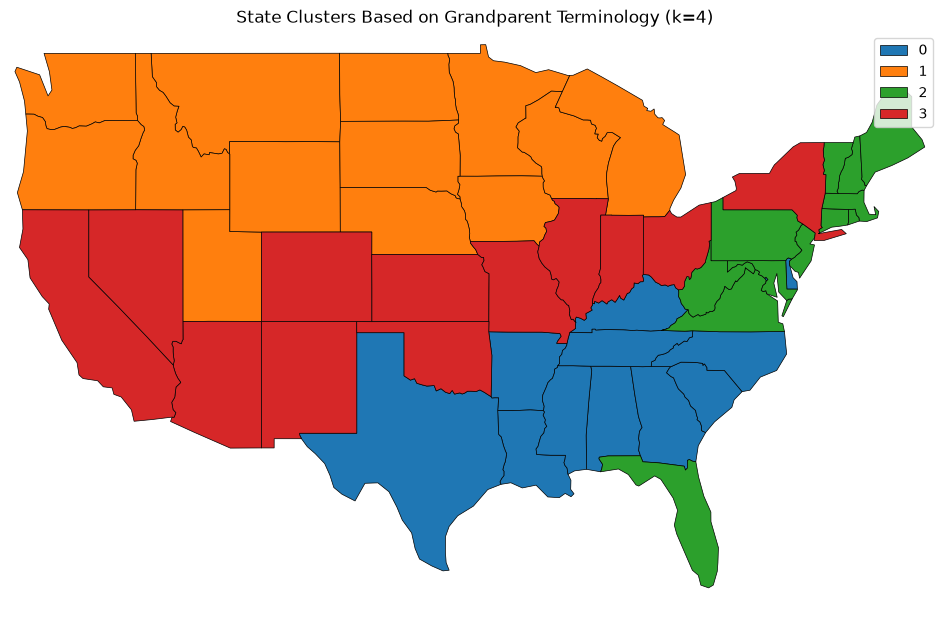

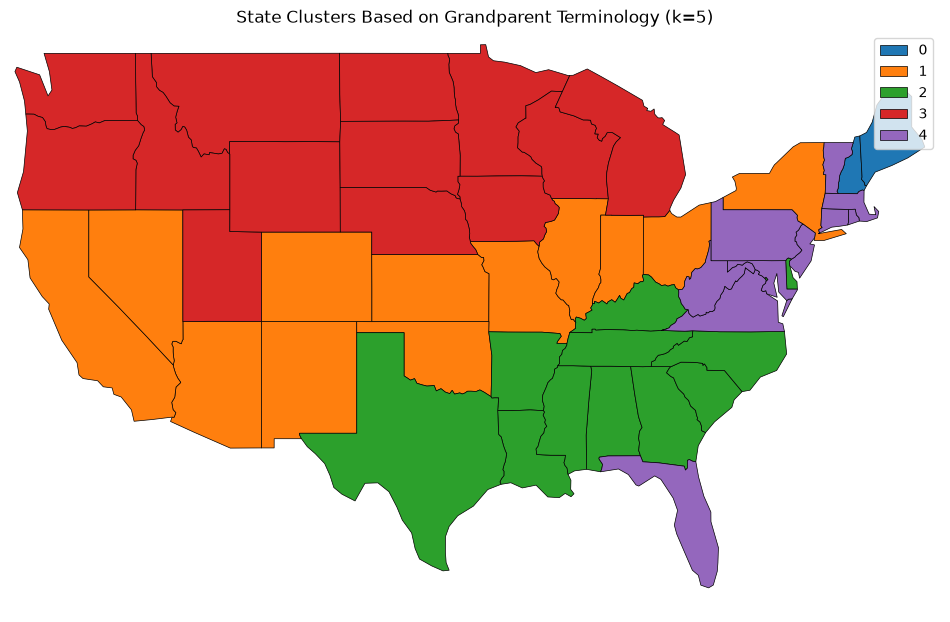

In [44]:
from sklearn.cluster import KMeans

for k in [3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    clusters = kmeans.fit_predict(state_profile)

    temp_cluster_df = pd.DataFrame({
        'STATE': state_profile.index,
        'cluster': clusters
    })

    temp_map = state_df.merge(
        temp_cluster_df,
        on='STATE',
        how='inner'
    )

    fig, ax = plt.subplots(figsize=(12, 8))

    temp_map.plot(
        column='cluster',
        categorical=True,
        legend=True,
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )

    ax.set_xlim(-125, -66)
    ax.set_ylim(24, 50)
    ax.set_title(f'State Clusters Based on Grandparent Terminology (k={k})')
    ax.axis('off')

    plt.show()

### Does a response to one question help predict the other?

Yes. Responses for maternal and paternal grandparents are strongly associated.

For the grandmother questions, 55.8% of respondents used the same response
category for their maternal and paternal grandmothers. The conditional
distributions also show strong correspondence. For example, among respondents
who used "grandma" for their maternal grandmother, 72.4% also used "grandma"
for their paternal grandmother. Similarly, among those who used "grandmother"
for their maternal grandmother, 61.5% used "grandmother" for their paternal
grandmother.

The relationship is also visible geographically. Across states, the maternal
and paternal usage rates are highly correlated for "granny" (r = 0.897) and
"nana" (r = 0.908).

A similar pattern appears for the grandfather questions. After harmonizing
categories that represent essentially the same terminology, 65.4% of
respondents used the same term for their maternal and paternal grandfathers.
For example, 80.1% of respondents who used "grandpa" for their maternal
grandfather also used "grandpa" for their paternal grandfather. State-level
usage rates were also strongly correlated for "grandpa" (r = 0.879),
"grampa" (r = 0.898), and "pap" (r = 0.843), although the correlation for
"gramps" was weaker (r = 0.323).

Overall, knowing the term a respondent uses for one grandparent provides
substantial information about the term they use for the corresponding
grandparent on the other side of the family. This is descriptive evidence of
predictive association rather than a formal out-of-sample prediction model.

 question3. 

In [45]:
question_cols = [
    col for col in ling_data.columns
    if col.startswith('Q')
]

print("Number of questions:", len(question_cols))
print(question_cols)

Number of questions: 67
['Q050', 'Q051', 'Q052', 'Q053', 'Q054', 'Q055', 'Q056', 'Q057', 'Q058', 'Q059', 'Q060', 'Q061', 'Q062', 'Q063', 'Q064', 'Q065', 'Q066', 'Q067', 'Q068', 'Q069', 'Q070', 'Q071', 'Q072', 'Q073', 'Q074', 'Q075', 'Q076', 'Q077', 'Q078', 'Q079', 'Q080', 'Q081', 'Q082', 'Q083', 'Q084', 'Q085', 'Q086', 'Q087', 'Q088', 'Q089', 'Q090', 'Q091', 'Q092', 'Q093', 'Q094', 'Q095', 'Q096', 'Q097', 'Q098', 'Q099', 'Q100', 'Q101', 'Q102', 'Q103', 'Q104', 'Q105', 'Q106', 'Q107', 'Q109', 'Q110', 'Q111', 'Q115', 'Q117', 'Q118', 'Q119', 'Q120', 'Q121']


In [46]:
binary_data = pd.get_dummies(
    ling_data[question_cols].astype(str),
    prefix=question_cols
).astype(int)

print("Original shape:", ling_data[question_cols].shape)
print("Binary shape:", binary_data.shape)

binary_data.head()

Original shape: (47471, 67)
Binary shape: (47471, 535)


,Q050_0,Q050_1,Q050_2,Q050_3,Q050_4,Q050_5,Q050_6,Q050_7,Q050_8,Q050_9,...,Q120_5,Q120_6,Q121_0,Q121_1,Q121_2,Q121_3,Q121_4,Q121_5,Q121_6,Q121_7
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


In [47]:
zero_cols = [col for col in binary_data.columns if col.endswith('_0')]

print("Number of no-response columns:", len(zero_cols))

binary_data = binary_data.drop(columns=zero_cols)

print("Final binary shape:", binary_data.shape)

Number of no-response columns: 67
Final binary shape: (47471, 468)


In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(binary_data)

print(pca.explained_variance_ratio_)
print("First 10 PCs:",
      pca.explained_variance_ratio_.sum())

[0.0403046  0.03457256 0.0304268  0.02586354 0.02076817 0.01890242
 0.01740833 0.01605412 0.0145984  0.012635  ]
First 10 PCs: 0.23153393579636286


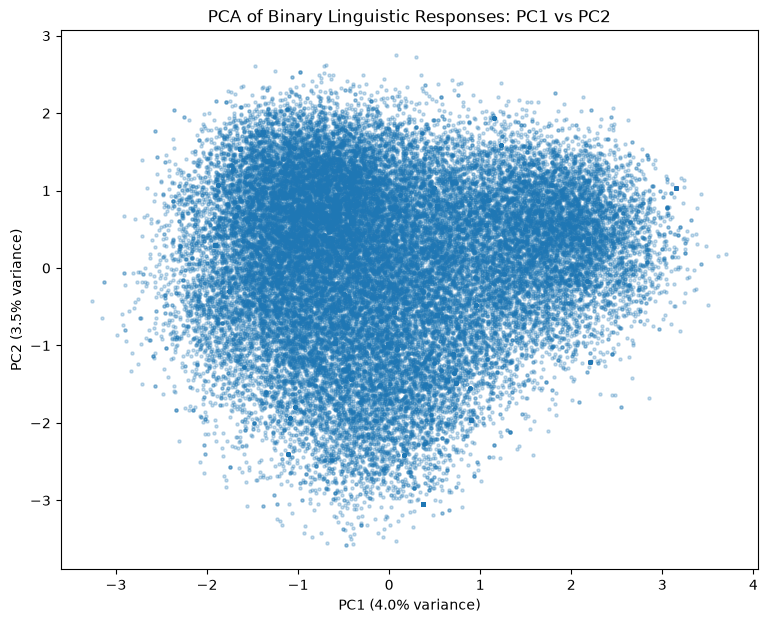

In [49]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=5,
    alpha=0.25
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)
plt.title("PCA of Binary Linguistic Responses: PC1 vs PC2")

plt.show()

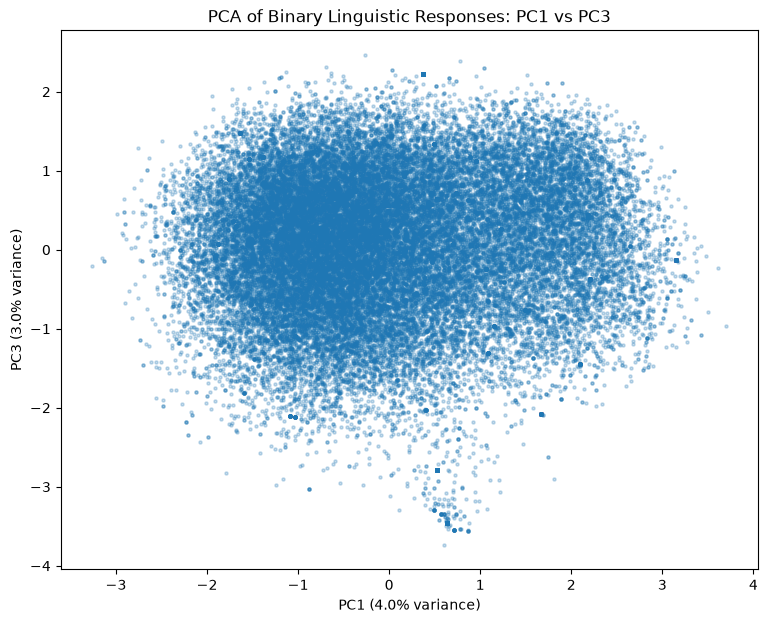

In [50]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 2],
    s=5,
    alpha=0.25
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% variance)"
)
plt.title("PCA of Binary Linguistic Responses: PC1 vs PC3")

plt.show()

# 
The PC1–PC2 projection did not reveal clearly separated clusters. Changing the projection to PC1–PC3 produced a somewhat different shape, but still did not reveal distinct groups. This suggests that linguistic response patterns may vary continuously rather than forming clearly separated clusters in the leading principal components.

In [51]:
pca_geo = ling_data[['lat', 'long']].copy()

pca_geo['PC1'] = X_pca[:, 0]
pca_geo['PC2'] = X_pca[:, 1]
pca_geo['PC3'] = X_pca[:, 2]

pca_geo = pca_geo.dropna()

pca_geo.head()

,lat,long,PC1,PC2,PC3
0,43.631230,-116.287161,-0.914153,0.384577,-0.603681
1,42.453840,-73.254003,1.095403,1.290863,0.182266
2,44.484038,-73.221265,0.927373,1.299841,0.401480
3,40.681798,-75.220820,2.008684,-0.153673,0.381684
4,42.496679,-71.275046,1.302463,0.270974,-0.788069


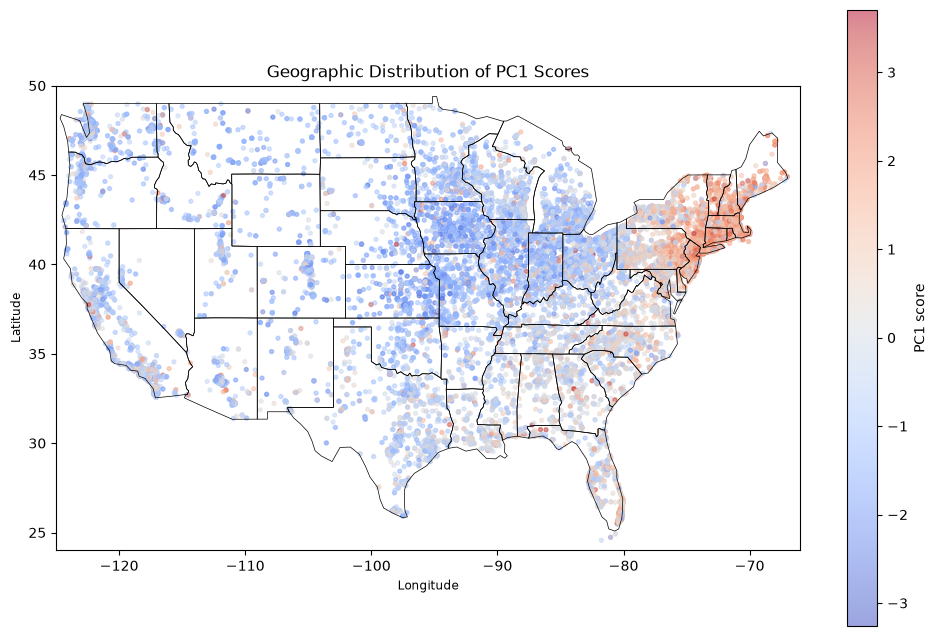

In [52]:
plt.figure(figsize=(12, 8))

plt.scatter(
    pca_geo['long'],
    pca_geo['lat'],
    c=pca_geo['PC1'],
    s=8,
    alpha=0.5,
    cmap='coolwarm'
)

state_df.boundary.plot(
    ax=plt.gca(),
    edgecolor='black',
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.colorbar(label='PC1 score')
plt.title('Geographic Distribution of PC1 Scores')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

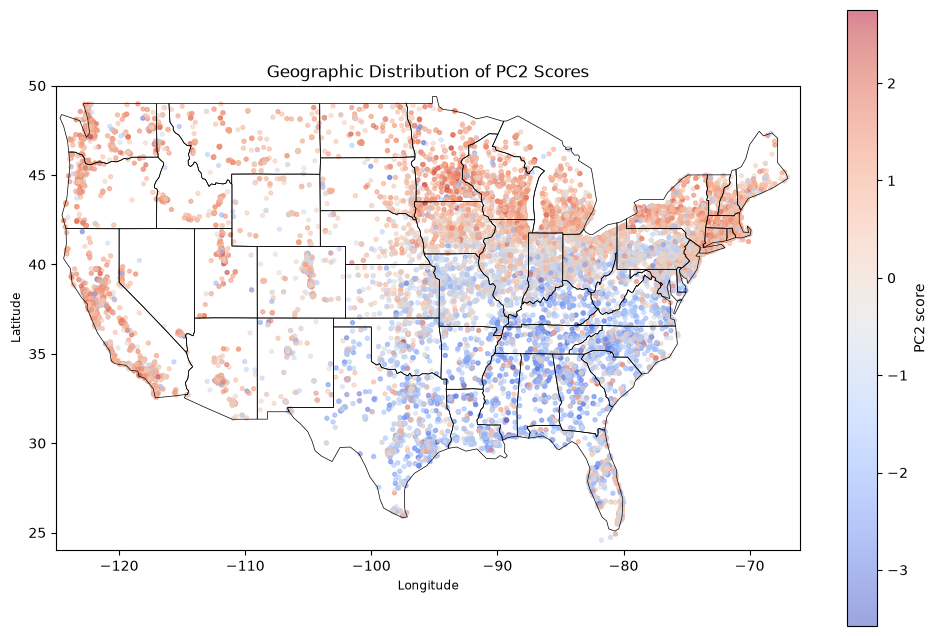

In [53]:
plt.figure(figsize=(12, 8))

plt.scatter(
    pca_geo['long'],
    pca_geo['lat'],
    c=pca_geo['PC2'],
    s=8,
    alpha=0.5,
    cmap='coolwarm'
)

state_df.boundary.plot(
    ax=plt.gca(),
    edgecolor='black',
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.colorbar(label='PC2 score')
plt.title('Geographic Distribution of PC2 Scores')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

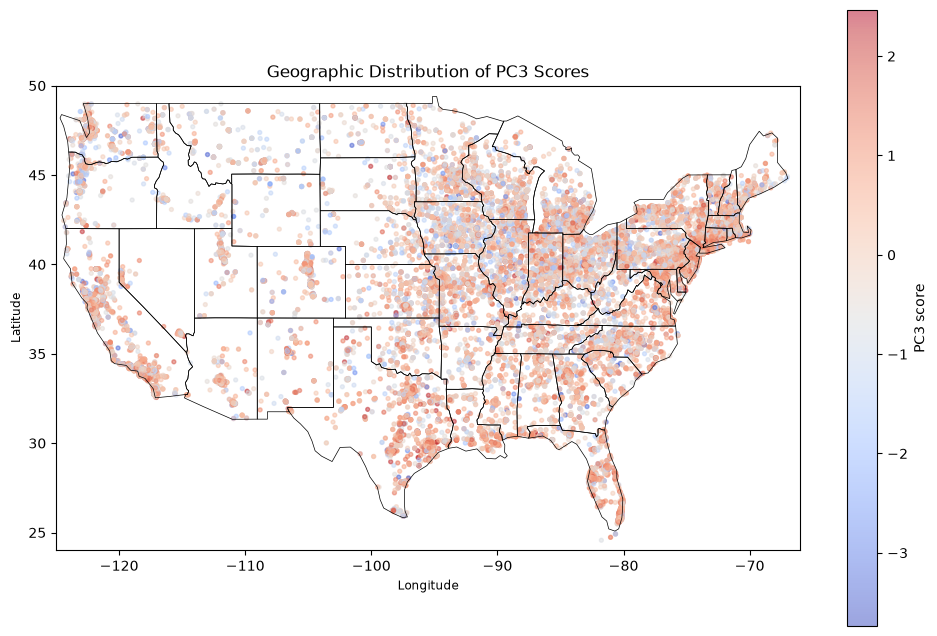

In [54]:
plt.figure(figsize=(12, 8))

plt.scatter(
    pca_geo['long'],
    pca_geo['lat'],
    c=pca_geo['PC3'],
    s=8,
    alpha=0.5,
    cmap='coolwarm'
)

state_df.boundary.plot(
    ax=plt.gca(),
    edgecolor='black',
    linewidth=0.5
)

plt.xlim(-125, -66)
plt.ylim(24, 50)

plt.colorbar(label='PC3 score')
plt.title('Geographic Distribution of PC3 Scores')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

The ordinary PCA scatter plots did not reveal distinct clusters. However, mapping the principal component scores geographically revealed clear spatial structure, especially for PC1 and PC2. PC2 appears to distinguish parts of the South and Southeast from northern and western regions. PC1 also shows geographic variation, while the geographic pattern in PC3 is less pronounced. Thus, the leading principal components appear to capture some regional variation in linguistic responses even though they do not form discrete clusters in the PCA scatter plots.

In [55]:
answered_count = binary_data.sum(axis=1)

print(answered_count.describe())

print("Correlation with PC1:",
      answered_count.corr(pd.Series(X_pca[:, 0], index=binary_data.index)))

print("Correlation with PC2:",
      answered_count.corr(pd.Series(X_pca[:, 1], index=binary_data.index)))

print("Correlation with PC3:",
      answered_count.corr(pd.Series(X_pca[:, 2], index=binary_data.index)))

count    47471.000000
mean        64.874450
std         10.586669
min          0.000000
25%         67.000000
50%         67.000000
75%         67.000000
max         67.000000
dtype: float64
Correlation with PC1: -0.09889109704670304
Correlation with PC2: 0.20436325197349559
Correlation with PC3: 0.5439058539035486


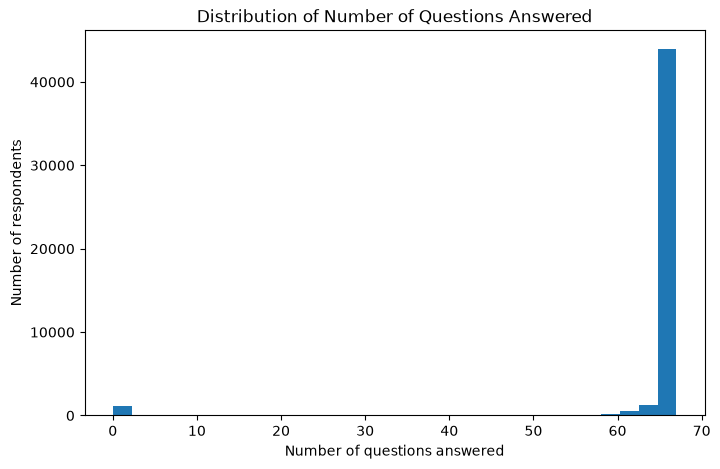

In [56]:
plt.figure(figsize=(8, 5))

plt.hist(answered_count, bins=30)

plt.xlabel("Number of questions answered")
plt.ylabel("Number of respondents")
plt.title("Distribution of Number of Questions Answered")

plt.show()

# 
only left people answered all 67 questions

In [57]:
complete_mask = answered_count == 67

binary_complete = binary_data.loc[complete_mask]

print("All respondents:", len(binary_data))
print("Complete respondents:", len(binary_complete))

All respondents: 47471
Complete respondents: 40061


In [58]:
pca_complete = PCA(n_components=10)

X_pca_complete = pca_complete.fit_transform(binary_complete)

print(pca_complete.explained_variance_ratio_)
print(
    "First 10 PCs:",
    pca_complete.explained_variance_ratio_.sum()
)

[0.04040305 0.03605785 0.02938486 0.02201967 0.02029956 0.01819514
 0.01726045 0.0162218  0.01372589 0.01295836]
First 10 PCs: 0.22652661334492827


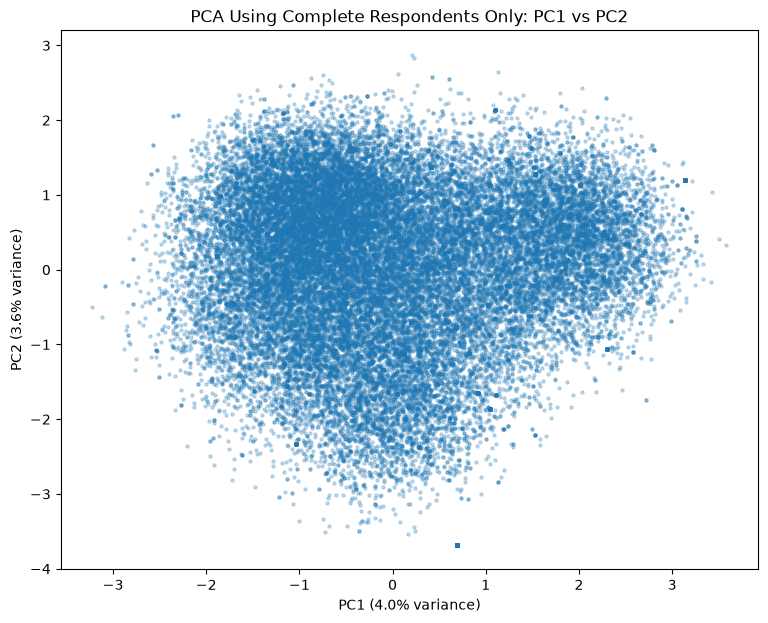

In [59]:
plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca_complete[:, 0],
    X_pca_complete[:, 1],
    s=5,
    alpha=0.25
)

plt.xlabel(
    f"PC1 ({pca_complete.explained_variance_ratio_[0]*100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca_complete.explained_variance_ratio_[1]*100:.1f}% variance)"
)
plt.title("PCA Using Complete Respondents Only: PC1 vs PC2")
plt.savefig(
    "../report/pca_pc1_pc2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Stability check: complete respondents

As a stability check, I repeated the PCA using only respondents who answered all 67 questions. Of the 44,771 respondents in the original analysis, 40,061 (about 89.5%) answered all 67 questions.

The results were very similar to the original PCA. In the original analysis, PC1 and PC2 explained about 4.03% and 3.46% of the variance, respectively. Among complete respondents, they explained about 4.04% and 3.61%. The first 10 principal components explained 23.15% of the variance in the original analysis and 22.65% among complete respondents.

The PC1-PC2 distribution also remained visually similar. This suggests that the main PCA structure, particularly PC1 and PC2, is not primarily driven by differences in survey completion.

In [60]:
pca_geo_complete = ling_data.loc[
    binary_complete.index,
    ['lat', 'long']
].copy()

pca_geo_complete['PC1'] = X_pca_complete[:, 0]
pca_geo_complete['PC2'] = X_pca_complete[:, 1]

pca_geo_complete = pca_geo_complete.dropna()

print(pca_geo_complete.shape)
pca_geo_complete.head()

(39218, 4)


,lat,long,PC1,PC2
16,33.825516,-86.242319,0.312692,0.094404
17,42.595491,-71.354402,1.095883,1.148739
19,42.173417,-71.049124,1.477041,1.449067
20,42.041999,-87.788824,-1.822360,0.798322
22,41.025114,-73.806353,2.213894,0.290642


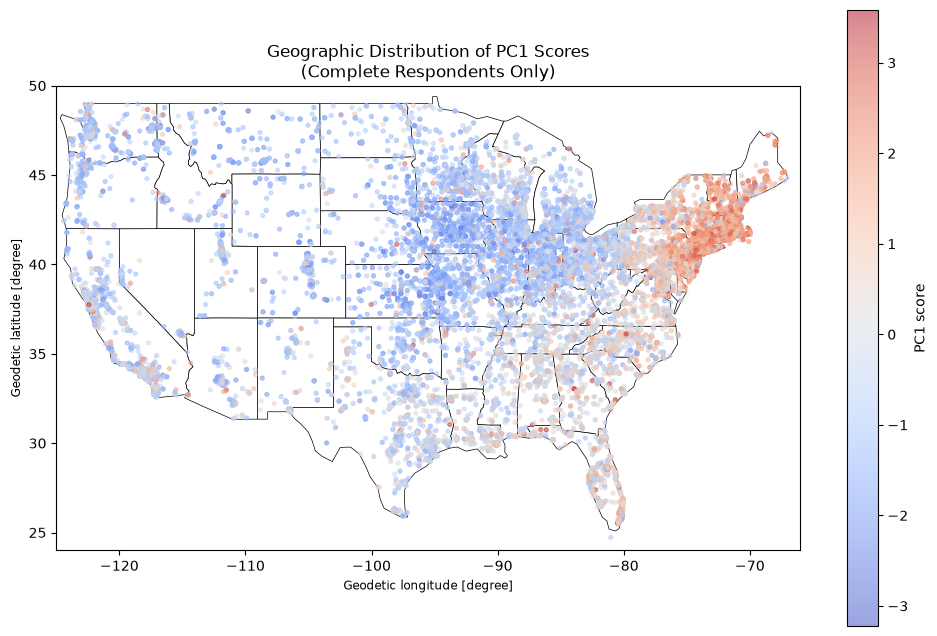

In [61]:
fig, ax = plt.subplots(figsize=(12, 8))

state_df.plot(
    ax=ax,
    facecolor='white',
    edgecolor='black',
    linewidth=0.5
)

sc = ax.scatter(
    pca_geo_complete['long'],
    pca_geo_complete['lat'],
    c=pca_geo_complete['PC1'],
    s=8,
    alpha=0.5,
    cmap='coolwarm'
)

plt.colorbar(sc, ax=ax, label='PC1 score')

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    'Geographic Distribution of PC1 Scores\n'
    '(Complete Respondents Only)'
)
plt.savefig(
    "../report/pca_pc1_geographic.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

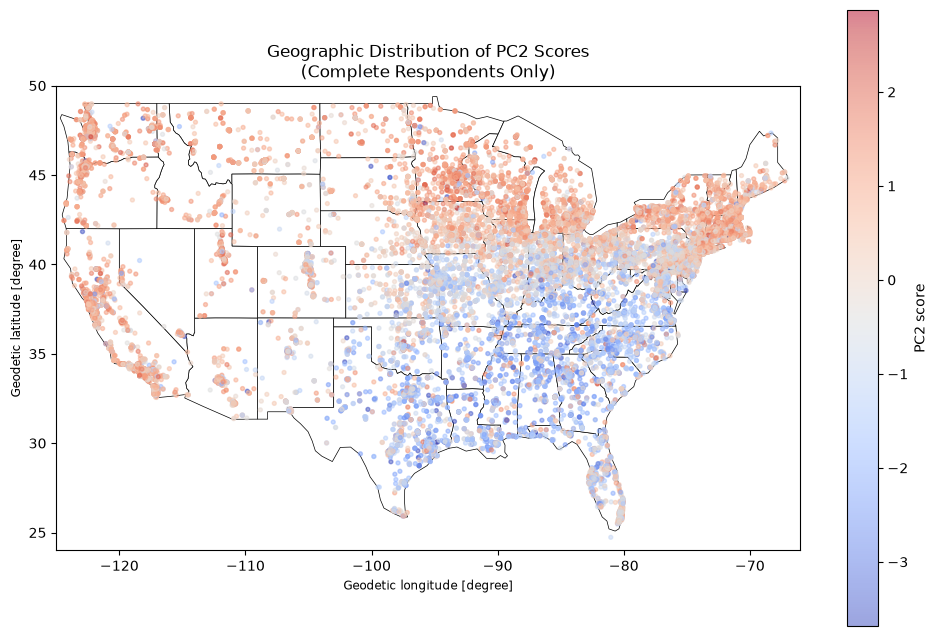

In [62]:
fig, ax = plt.subplots(figsize=(12, 8))

state_df.plot(
    ax=ax,
    facecolor='white',
    edgecolor='black',
    linewidth=0.5
)

sc = ax.scatter(
    pca_geo_complete['long'],
    pca_geo_complete['lat'],
    c=pca_geo_complete['PC2'],
    s=8,
    alpha=0.5,
    cmap='coolwarm'
)

plt.colorbar(sc, ax=ax, label='PC2 score')

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    'Geographic Distribution of PC2 Scores\n'
    '(Complete Respondents Only)'
)
plt.savefig(
    "../report/pca_pc2_geographic.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Stability Check

As a stability check, I repeated the PCA using only respondents who answered all 67 questions. Of the 44,771 respondents in the original analysis, 40,061 (about 89.5%) answered all 67 questions.

The PCA results were very similar after this restriction. In the original analysis, PC1 and PC2 explained about 4.03% and 3.46% of the variance, respectively. Among complete respondents, they explained about 4.04% and 3.61%. The first 10 principal components explained 23.15% of the variance in the original analysis and 22.65% among complete respondents.

The geographic patterns were also very similar. The PC1 map continued to show relatively high scores in the Northeast and lower scores in parts of the Midwest and central United States. The PC2 map also retained its broad geographic pattern, with relatively higher scores across much of the northern United States and lower scores across much of the South.

Overall, the similarity of the explained variance, PCA scatterplots, and geographic patterns suggests that the main PCA results are not primarily driven by respondents with incomplete survey responses.

In [63]:
feature_names = binary_data.columns

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(10)]
)

for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\n===== {pc}: most positive loadings =====")
    print(loadings[pc].sort_values(ascending=False).head(15))

    print(f"\n===== {pc}: most negative loadings =====")
    print(loadings[pc].sort_values().head(15))


===== PC1: most positive loadings =====
Q073_1    0.258415
Q105_1    0.184970
Q080_1    0.178943
Q056_2    0.145935
Q078_2    0.139411
Q095_1    0.134713
Q086_1    0.132031
Q103_4    0.130461
Q119_1    0.117175
Q099_2    0.109612
Q098_1    0.102402
Q070_7    0.099323
Q110_3    0.093587
Q058_2    0.091938
Q066_2    0.091242
Name: PC1, dtype: float64

===== PC1: most negative loadings =====
Q073_6   -0.244869
Q080_8   -0.187591
Q106_1   -0.176409
Q105_2   -0.172950
Q103_3   -0.158287
Q056_1   -0.152971
Q099_1   -0.142994
Q066_5   -0.137104
Q095_6   -0.135584
Q058_3   -0.132837
Q064_1   -0.129707
Q087_1   -0.123310
Q068_3   -0.121779
Q074_4   -0.117070
Q078_1   -0.115061
Name: PC1, dtype: float64

===== PC2: most positive loadings =====
Q076_1    0.247996
Q103_3    0.178331
Q118_7    0.170394
Q100_4    0.161706
Q065_2    0.160822
Q068_3    0.157604
Q089_3    0.151874
Q069_3    0.146273
Q094_1    0.138581
Q066_2    0.130427
Q106_1    0.128420
Q050_4    0.127416
Q119_1    0.126981
Q105_1  

In [64]:
def get_feature_label(feature):
    # Example: Q073_1 -> question 73, response 1
    q_part, response_part = feature.split('_')

    qnum = int(q_part[1:])
    response_code = int(response_part)

    # Get question text
    question_row = question_data['quest.mat'][
        question_data['quest.mat']['qnum'] == qnum
    ]

    if len(question_row) > 0:
        question_text = question_row['quest'].iloc[0]
    else:
        question_text = "Question not found"

    # Get answer text
    answer_key = f'ans.{qnum}'

    if answer_key in question_data and response_code > 0:
        answers = question_data[answer_key]

        if response_code <= len(answers):
            answer_text = answers.iloc[response_code - 1]['ans']
        else:
            answer_text = "Answer not found"
    else:
        answer_text = "No response"

    return question_text, answer_text

In [65]:
for pc in ['PC1', 'PC2']:

    print(f"\n\n========== {pc}: POSITIVE ==========")

    top_positive = loadings[pc].sort_values(
        ascending=False
    ).head(10)

    for feature, loading in top_positive.items():
        question, answer = get_feature_label(feature)

        print(f"\n{feature}   loading = {loading:.3f}")
        print("Question:", question)
        print("Answer:", answer)


    print(f"\n\n========== {pc}: NEGATIVE ==========")

    top_negative = loadings[pc].sort_values().head(10)

    for feature, loading in top_negative.items():
        question, answer = get_feature_label(feature)

        print(f"\n{feature}   loading = {loading:.3f}")
        print("Question:", question)
        print("Answer:", answer)



========== PC1: POSITIVE ==========

Q073_1   loading = 0.258
Question: What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?
Answer: sneakers 

Q105_1   loading = 0.185
Question: What is your generic term for a sweetened carbonated beverage?
Answer: soda

Q080_1   loading = 0.179
Question: What do you call it when rain falls while the sun is shining?
Answer: sunshower 

Q056_2   loading = 0.146
Question: Pantyhose are so expensive anymore that I just try to get a good suntan and forget about it.
Answer: unacceptable 

Q078_2   loading = 0.139
Question: What do you call paper that has already been used for something or is otherwise imperfect?
Answer: scrap paper 

Q095_1   loading = 0.135
Question: What is 'the City'?
Answer: New York City 

Q086_1   loading = 0.132
Question: Do you use the word cruller?
Answer: yes 

Q103_4   loading = 0.130
Question: What do you call the thing from which you might drink water in a school?
Answer: w

### Interpretation of the principal components

The loadings suggest that the first two principal components capture meaningful regional linguistic variation rather than arbitrary differences in survey responses.

PC1 contrasts several alternative terms for the same concepts. For example, "sneakers," "soda," and "water fountain" have relatively large positive loadings, while "tennis shoes," "pop," and "drinking fountain" have relatively large negative loadings. Combined with the geographic distribution of PC1 scores, this component appears to capture a broad regional linguistic contrast, with relatively high scores in the Northeast and lower scores across parts of the Midwest and central United States.

PC2 shows another clear regional contrast. Responses such as "kitty-corner," "firefly," and "frosting" have positive loadings, while "catty-corner," "y'all," "coke," "lightning bug," and "icing" have negative loadings. The geographic map shows lower PC2 scores across much of the South and higher scores across much of the northern United States. This suggests that PC2 captures a broad North-South dimension of linguistic variation.

These interpretations should not be treated as formal dialect classifications. PCA was performed using linguistic responses without geographic information, and the geographic patterns were examined afterward.

### Centering and scaling

I centered the binary variables but did not scale them before PCA. Scikit-learn's PCA centers each variable automatically. I chose not to standardize the binary variables because scaling binary indicators would give relatively rare response categories disproportionately large weights. Keeping the variables on their original 0/1 scale makes the PCA reflect variation in the observed response indicators.

### Why not use PCA on the original categorical data?

It would not be appropriate to apply PCA directly to the original categorical lingData variables because the numerical response codes represent categories rather than meaningful numerical quantities. For example, response 2 is not necessarily closer to response 3 than to response 6. Applying PCA directly to these codes would therefore impose artificial ordering and distances between response categories. Binary encoding avoids this problem by representing each response category as a separate indicator variable.

question #4

k-means

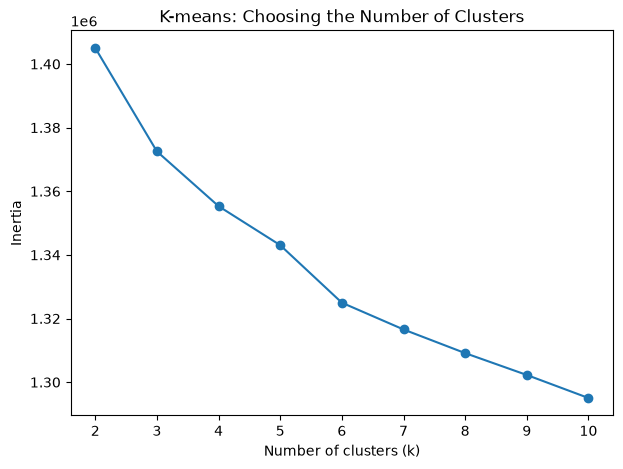

In [66]:
from sklearn.cluster import KMeans

ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(binary_complete)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means: Choosing the Number of Clusters")
plt.show()

# 
silhouette score for sample of 5,000 people

In [67]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(binary_complete)

    score = silhouette_score(
        binary_complete,
        labels,
        sample_size=5000,
        random_state=42
    )

    silhouette_scores.append(score)
    print(k, round(score, 4))

2 0.0302


3 0.032


4 0.0277


5 0.0255


6 0.0214


7 0.0208


8 0.0184


9 0.0213


10 0.0227


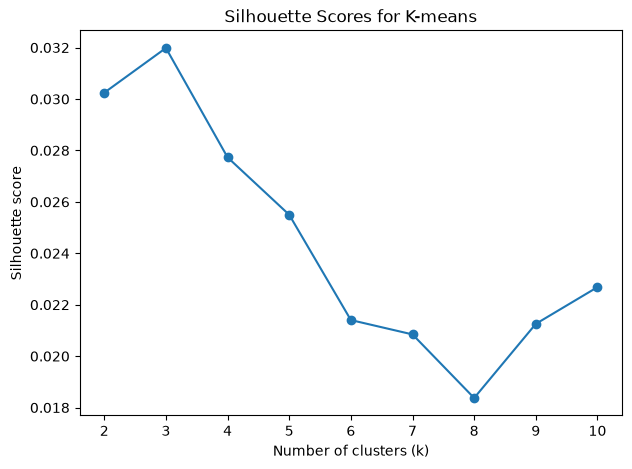

In [68]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores for K-means")

plt.show()

Although k = 3 produced the highest silhouette score among the values considered, the score was very low (0.032). This suggests that the linguistic responses do not form sharply separated clusters. Instead, the data appear to show substantial overlap and a more continuous pattern of linguistic variation.

In [69]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans_final.fit_predict(binary_complete)

pd.Series(cluster_labels).value_counts().sort_index()

0    11433
1    11406
2    17222
Name: count, dtype: int64

In [70]:
cluster_geo = ling_data.loc[
    binary_complete.index,
    ['lat', 'long']
].copy()

cluster_geo['cluster'] = cluster_labels

cluster_geo = cluster_geo.dropna()

print(cluster_geo.shape)
cluster_geo.head()

(39218, 3)


,lat,long,cluster
16,33.825516,-86.242319,0
17,42.595491,-71.354402,1
19,42.173417,-71.049124,1
20,42.041999,-87.788824,2
22,41.025114,-73.806353,1


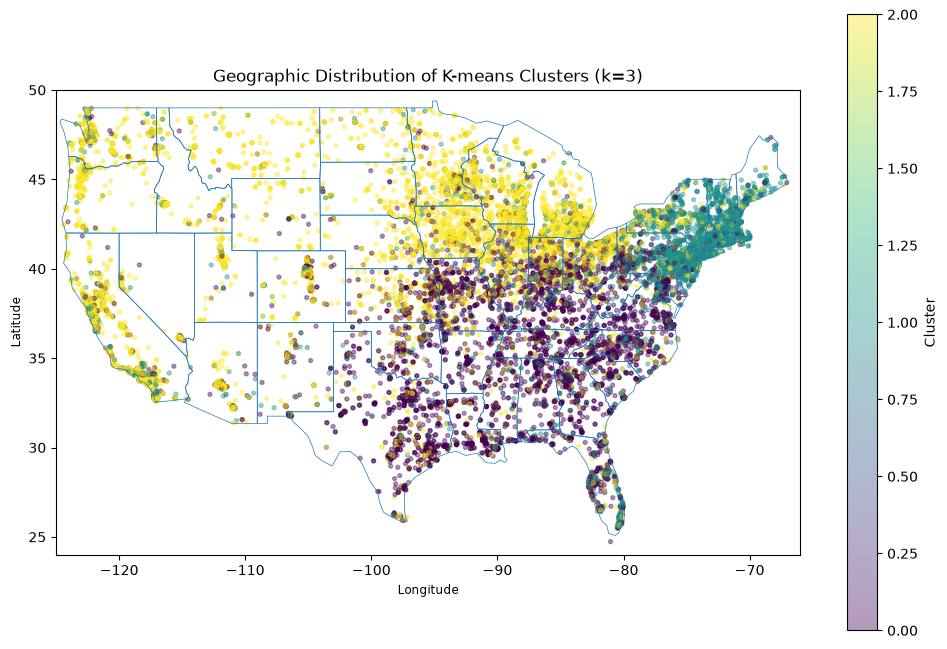

In [71]:
fig, ax = plt.subplots(figsize=(12, 8))

state_df.boundary.plot(
    ax=ax,
    linewidth=0.5
)

scatter = ax.scatter(
    cluster_geo['long'],
    cluster_geo['lat'],
    c=cluster_geo['cluster'],
    s=8,
    alpha=0.4,
    cmap='viridis'
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution of K-means Clusters (k=3)")

plt.colorbar(scatter, ax=ax, label="Cluster")

plt.savefig(
    "../report/kmeans_clusters_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
cluster_binary = binary_complete.copy()
cluster_binary['cluster'] = cluster_labels

cluster_means = cluster_binary.groupby('cluster').mean()

for cluster in cluster_means.index:
    print(f"\n===== Cluster {cluster} =====")
    
    top = (
        cluster_means.loc[cluster]
        .sort_values(ascending=False)
        .head(15)
    )
    
    print(top)


===== Cluster 0 =====
Q063_1    0.990816
Q093_2    0.980408
Q077_1    0.907723
Q103_4    0.896440
Q081_1    0.890667
Q110_8    0.851308
Q104_1    0.851133
Q062_2    0.850608
Q067_1    0.849821
Q054_2    0.841074
Q055_2    0.837838
Q064_1    0.820345
Q115_1    0.806962
Q051_2    0.796554
Q092_3    0.795417
Name: 0, dtype: float64

===== Cluster 1 =====
Q067_1    0.965457
Q054_2    0.957479
Q109_1    0.946432
Q055_2    0.939944
Q053_2    0.923987
Q063_1    0.919516
Q098_1    0.904349
Q115_1    0.896809
Q081_1    0.896283
Q073_1    0.887603
Q092_3    0.879274
Q091_2    0.861389
Q119_1    0.847799
Q105_1    0.842802
Q075_1    0.831843
Name: 1, dtype: float64

===== Cluster 2 =====
Q063_1    0.990942
Q093_2    0.978980
Q067_1    0.965858
Q053_2    0.933806
Q054_2    0.918534
Q081_1    0.915167
Q064_1    0.902625
Q092_3    0.867727
Q055_2    0.865172
Q115_1    0.852166
Q109_1    0.840669
Q062_2    0.839972
Q106_1    0.825978
Q110_8    0.806352
Q104_1    0.797236
Name: 2, dtype: float64


In [73]:
cluster_diff = cluster_means.max(axis=0) - cluster_means.min(axis=0)

top_diff_features = (
    cluster_diff
    .sort_values(ascending=False)
    .head(20)
)

top_diff_features

Q073_1    0.736549
Q073_6    0.707780
Q076_1    0.611926
Q103_4    0.595952
Q105_1    0.564048
Q103_3    0.553205
Q076_4    0.551057
Q105_2    0.469793
Q050_9    0.465774
Q106_1    0.418211
Q066_2    0.412217
Q080_1    0.409638
Q099_1    0.398150
Q118_7    0.397094
Q105_3    0.390751
Q080_8    0.387790
Q074_4    0.381325
Q089_1    0.381208
Q078_2    0.366234
Q119_1    0.350642
dtype: float64

In [74]:
cluster_means[
    top_diff_features.index
].T

cluster,0,1,2
Q073_1,0.151054,0.887603,0.172454
Q073_6,0.742850,0.035069,0.633144
Q076_1,0.122890,0.401631,0.734816
Q103_4,0.896440,0.766176,0.300488
Q105_1,0.278754,0.842802,0.355243
Q103_3,0.085454,0.144661,0.638660
Q076_4,0.700691,0.269157,0.149634
Q105_2,0.172133,0.050587,0.520381
Q050_9,0.511064,0.060670,0.045291
Q106_1,0.478615,0.407768,0.825978


In [75]:
for feature in top_diff_features.index:
    print(feature)
    print(get_feature_label(feature))
    print(
        "Cluster proportions:",
        cluster_means.loc[:, feature].round(3).to_dict()
    )
    print()

Q073_1
('What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?', 'sneakers ')
Cluster proportions: {0: 0.151, 1: 0.888, 2: 0.172}

Q073_6
('What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?', 'tennis shoes ')
Cluster proportions: {0: 0.743, 1: 0.035, 2: 0.633}

Q076_1
('What term do you use to refer to something that is across both streets from you at an intersection (or diagonally across from you in general)?', 'kitty-corner ')
Cluster proportions: {0: 0.123, 1: 0.402, 2: 0.735}

Q103_4
('What do you call the thing from which you might drink water in a school?', 'water fountain ')
Cluster proportions: {0: 0.896, 1: 0.766, 2: 0.3}

Q105_1
('What is your generic term for a sweetened carbonated beverage?', 'soda')
Cluster proportions: {0: 0.279, 1: 0.843, 2: 0.355}

Q103_3
('What do you call the thing from which you might drink water in a school?', 'drinking fountain ')
Cluster propo

### K-means clustering

I used K-means clustering on the binary linguistic response variables. 
I chose k = 3 because it had the highest silhouette score among the 
values considered, although the silhouette score was quite low (0.032). 
This suggests that the respondents do not form sharply separated clusters.

Despite the weak separation in the response space, the three clusters 
showed a clear geographic pattern. Cluster 0 was concentrated primarily 
in the South and Southeast, Cluster 1 was concentrated in the Northeast, 
and Cluster 2 was more common across the West, Upper Midwest, and other 
northern areas. The clusters overlap substantially, especially in 
transitional regions.

Several responses strongly distinguished the clusters. For example, 
"sneakers" was used by 88.8% of Cluster 1 compared with about 15-17% 
of the other clusters. "Y'all" was used by 51.1% of Cluster 0 but only 
6.1% and 4.5% of Clusters 1 and 2. "Pop" was most common in Cluster 2 
(52.0%), while "soda" was especially common in Cluster 1 (84.3%). 
Other strong contrasts included catty-corner versus kitty-corner and 
water fountain versus drinking fountain.

Overall, the clustering suggests substantial geographic structure in 
linguistic responses, but the very low silhouette score and geographic 
overlap suggest a continuum of linguistic variation rather than three 
sharply separated dialect groups.

spectral clustering

In [76]:
import numpy as np

rng = np.random.default_rng(42)

sample_idx = rng.choice(
    len(binary_complete),
    size=10000,
    replace=False
)

X_spectral_sample = X_pca_complete[sample_idx, :10]

print(X_spectral_sample.shape)

(10000, 10)


In [77]:
from sklearn.cluster import SpectralClustering
import time

start = time.time()

spectral = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    n_neighbors=10,
    assign_labels="kmeans",
    random_state=42,
    n_jobs=-1
)

spectral_labels_sample = spectral.fit_predict(
    X_spectral_sample
)

print(
    "Time:",
    round(time.time() - start, 1),
    "seconds"
)

/opt/miniconda3/envs/stat215a/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Time: 19.2 seconds


In [78]:
pd.Series(
    spectral_labels_sample
).value_counts().sort_index()

0    9948
1      23
2      29
Name: count, dtype: int64

In [79]:
spectral_50 = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    n_neighbors=50,
    assign_labels="kmeans",
    random_state=42,
    n_jobs=-1
)

spectral_labels_50 = spectral_50.fit_predict(
    X_spectral_sample
)

pd.Series(
    spectral_labels_50
).value_counts().sort_index()

/opt/miniconda3/envs/stat215a/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


0    9760
1     175
2      65
Name: count, dtype: int64

In [80]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import connected_components

for n_neighbors in [10, 20, 50, 100, 200]:
    
    graph = kneighbors_graph(
        X_spectral_sample,
        n_neighbors=n_neighbors,
        mode='connectivity',
        include_self=False
    )

    # Make the graph symmetric
    graph = graph.maximum(graph.T)

    n_components, labels = connected_components(
        graph,
        directed=False
    )

    component_sizes = np.bincount(labels)

    print(
        "n_neighbors =", n_neighbors,
        "| connected components =", n_components,
        "| largest component =", component_sizes.max()
    )

n_neighbors = 10 | connected components = 7 | largest component = 9628


n_neighbors = 20 | connected components = 5 | largest component = 9681


n_neighbors = 50 | connected components = 3 | largest component = 9760


n_neighbors = 100 | connected components = 2 | largest component = 9825


n_neighbors = 200 | connected components = 1 | largest component = 10000


In [81]:
spectral_200 = SpectralClustering(
    n_clusters=3,
    affinity="nearest_neighbors",
    n_neighbors=200,
    assign_labels="kmeans",
    random_state=42,
    n_jobs=-1
)

spectral_labels_200 = spectral_200.fit_predict(
    X_spectral_sample
)

pd.Series(
    spectral_labels_200
).value_counts().sort_index()

0    7425
1    2398
2     177
Name: count, dtype: int64

In [82]:
spectral_indices = binary_complete.index[sample_idx]

spectral_geo = ling_data.loc[
    spectral_indices,
    ['lat', 'long']
].copy()

spectral_geo['cluster'] = spectral_labels_200

spectral_geo = spectral_geo.dropna()

print(spectral_geo.shape)
spectral_geo.head()

(9800, 3)


,lat,long,cluster
25905,32.901176,-96.790549,0
24410,40.701702,-73.675624,1
18028,40.459518,-79.832770,2
37377,29.690230,-95.434742,0
21575,30.207559,-97.795751,0


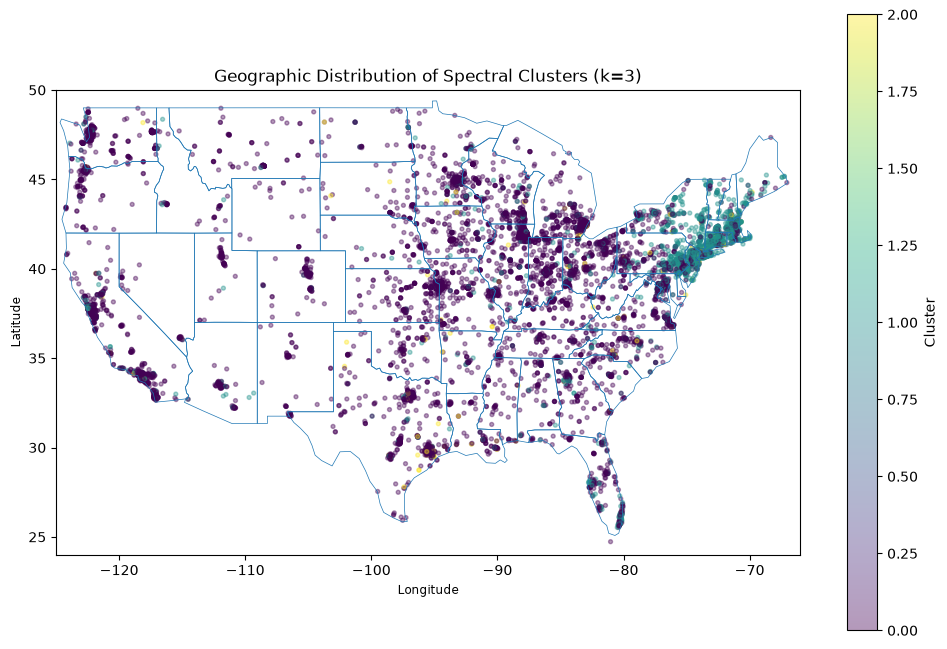

In [83]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    spectral_geo['long'],
    spectral_geo['lat'],
    c=spectral_geo['cluster'],
    s=8,
    alpha=0.4,
    cmap='viridis'
)

state_df.boundary.plot(
    ax=ax,
    linewidth=0.5
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Geographic Distribution of Spectral Clusters (k=3)"
)

plt.colorbar(scatter, ax=ax, label="Cluster")

plt.savefig(
    "../report/spectral_clusters_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

k-means vs spectral

In [84]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# K-means labels for the same 10,000 respondents
kmeans_labels_sample = cluster_labels[sample_idx]

print("K-means cluster sizes:")
print(pd.Series(kmeans_labels_sample).value_counts().sort_index())

print("\nSpectral cluster sizes:")
print(pd.Series(spectral_labels_200).value_counts().sort_index())

print(
    "\nAdjusted Rand Index:",
    round(
        adjusted_rand_score(
            kmeans_labels_sample,
            spectral_labels_200
        ),
        3
    )
)

print(
    "Normalized Mutual Information:",
    round(
        normalized_mutual_info_score(
            kmeans_labels_sample,
            spectral_labels_200
        ),
        3
    )
)

K-means cluster sizes:
0    2919
1    2844
2    4237
Name: count, dtype: int64

Spectral cluster sizes:
0    7425
1    2398
2     177
Name: count, dtype: int64

Adjusted Rand Index: 0.387
Normalized Mutual Information: 0.51


In [85]:
comparison = pd.crosstab(
    kmeans_labels_sample,
    spectral_labels_200,
    rownames=["K-means"],
    colnames=["Spectral"]
)

comparison

Spectral,0,1,2
K-means,,,
0,2734,8,177
1,454,2390,0
2,4237,0,0


In [86]:
spectral_binary = binary_complete.iloc[sample_idx].copy()
spectral_binary["cluster"] = spectral_labels_200

spectral_means = spectral_binary.groupby("cluster").mean()

spectral_diff = (
    spectral_means.max(axis=0)
    - spectral_means.min(axis=0)
)

spectral_top_features = (
    spectral_diff
    .sort_values(ascending=False)
    .head(20)
)

spectral_top_features

Q106_4    0.989763
Q099_4    0.987907
Q105_3    0.984153
Q074_2    0.982257
Q073_6    0.979983
Q098_3    0.953254
Q050_9    0.941201
Q091_3    0.919705
Q098_1    0.917431
Q073_1    0.914095
Q119_3    0.911364
Q092_2    0.910983
Q084_2    0.884676
Q105_1    0.875313
Q101_3    0.866142
Q092_3    0.865910
Q119_1    0.865493
Q091_2    0.859655
Q107_2    0.850512
Q072_5    0.820613
dtype: float64

In [87]:
spectral_means[
    spectral_top_features.index
].T

cluster,0,1,2
Q106_4,0.027071,0.004587,0.994350
Q099_4,0.029495,0.012093,1.000000
Q105_3,0.175892,0.015847,1.000000
Q074_2,0.045791,0.012093,0.994350
Q073_6,0.634613,0.020017,1.000000
Q098_3,0.135623,0.035446,0.988701
Q050_9,0.208620,0.058799,1.000000
Q091_3,0.128215,0.074646,0.994350
Q098_1,0.684579,0.917431,0.000000
Q073_1,0.211178,0.914095,0.000000


In [88]:
for feature in spectral_top_features.index:
    print(feature)
    print(get_feature_label(feature))
    print(
        "Cluster proportions:",
        spectral_means.loc[:, feature].round(3).to_dict()
    )
    print()

Q106_4
('What do you call the act of covering a house or area in front of a house with toilet paper?', 'wrapping ')
Cluster proportions: {0: 0.027, 1: 0.005, 2: 0.994}

Q099_4
('Which of these terms do you prefer for the small road parallel to the highway?', 'feeder road ')
Cluster proportions: {0: 0.029, 1: 0.012, 2: 1.0}

Q105_3
('What is your generic term for a sweetened carbonated beverage?', 'coke')
Cluster proportions: {0: 0.176, 1: 0.016, 2: 1.0}

Q074_2
('What do you call the little gray creature (that looks like an insect but is actually a crustacean) that rolls up into a ball when you touch it?', 'doodle bug ')
Cluster proportions: {0: 0.046, 1: 0.012, 2: 0.994}

Q073_6
('What is your *general* term for the rubber-soled shoes worn in gym class, for athletic activities, etc.?', 'tennis shoes ')
Cluster proportions: {0: 0.635, 1: 0.02, 2: 1.0}

Q098_3
('Which of these terms do you prefer?', 'both')
Cluster proportions: {0: 0.136, 1: 0.035, 2: 0.989}

Q050_9
('What word(s) do yo

### Spectral Clustering

As a second clustering method, I applied spectral clustering to a reproducible random subsample of 10,000 complete respondents. Because spectral clustering was computationally expensive on the full binary data, I used the first 10 principal components as the input representation.

I constructed a nearest-neighbor graph. With small values of the number of neighbors, the graph was disconnected. For example, using 50 neighbors produced three disconnected components, which largely determined the resulting clusters. I therefore increased the neighborhood size to 200, at which point the graph became fully connected.

Using three clusters, spectral clustering produced groups of 7,425, 2,398, and 177 respondents. The clusters were therefore much more unbalanced than the K-means clusters.

The second spectral cluster showed a clear geographic concentration in the Northeast and was characterized by responses such as "sneakers," "soda," and "take-out." This broadly corresponded to one of the regional patterns identified by K-means.

The third spectral cluster contained only 177 respondents and had a highly distinctive response profile. Nearly all respondents in this cluster selected responses such as "coke," "tennis shoes," "y'all," "feeder road," and several other specific terms. However, this small cluster did not appear to form a clearly concentrated geographic region, so I would not interpret it as a separate dialect region without further investigation.

The two clustering methods shared some structure but produced substantially different partitions. The Adjusted Rand Index between K-means and spectral clustering was 0.387 and the normalized mutual information was 0.510. In particular, the Northeastern cluster was fairly consistent across the two methods, whereas K-means separated the remaining respondents into two large regional clusters and spectral clustering largely combined them into one dominant cluster.

### Comparison of Clustering Methods

K-means was computationally efficient and produced three relatively large and geographically interpretable groups. It was also easy to interpret by comparing cluster-specific response proportions. However, K-means relies on Euclidean distance and centroid-based partitions, and the very low silhouette score indicated that the clusters were not sharply separated.

Spectral clustering can capture structure that is not well represented by simple centroid-based partitions because it uses a similarity graph and its eigenvectors. In this analysis, it recovered a Northeastern linguistic cluster that was also visible in K-means, suggesting that this pattern is relatively robust to clustering method.

However, spectral clustering was much more computationally demanding and highly sensitive to construction of the nearest-neighbor graph. Small neighborhood sizes produced disconnected graphs, and even after obtaining a connected graph, the resulting cluster sizes were highly unbalanced. Thus, spectral clustering revealed some interesting local structure but was less straightforward to interpret as a partition of the full U.S. population.

Eigenvalues:
[2.66171633e-16 6.36996791e-02 1.10772056e-01 1.43962462e-01
 2.10911523e-01 2.45341117e-01 2.90412337e-01 3.19024938e-01
 3.34068407e-01 3.37268634e-01]

Eigengaps:
[0.06369968 0.04707238 0.03319041 0.06694906 0.03442959 0.04507122
 0.0286126  0.01504347 0.00320023]


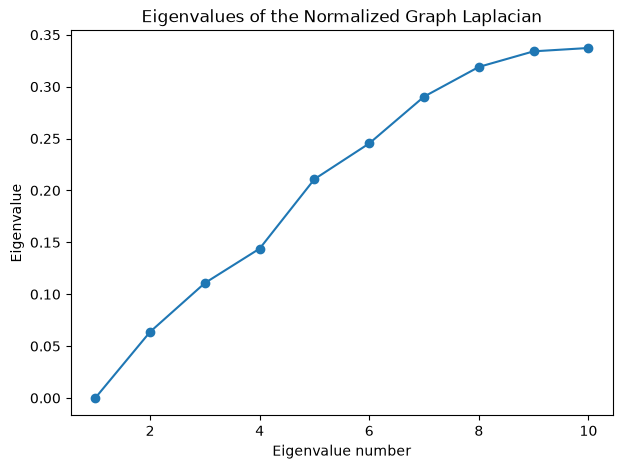

In [89]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
import numpy as np
import matplotlib.pyplot as plt

# Same graph used for spectral clustering
graph = kneighbors_graph(
    X_spectral_sample,
    n_neighbors=200,
    mode="connectivity",
    include_self=False
)

graph = graph.maximum(graph.T)

# Normalized graph Laplacian
L = laplacian(graph, normed=True)

# Smallest 10 eigenvalues
eigenvalues, eigenvectors = eigsh(L, k=10, which="SM")
eigenvalues = np.sort(eigenvalues)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigengaps:")
print(np.diff(eigenvalues))

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), eigenvalues, marker="o")
plt.xlabel("Eigenvalue number")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of the Normalized Graph Laplacian")
plt.show()

The eigengap heuristic did not provide strong support for three clusters. The largest relevant gap occurred between the fourth and fifth eigenvalues, suggesting that four clusters may also be a reasonable choice. I nevertheless used k=3 for the spectral clustering analysis to facilitate direct comparison with the three-cluster K-means solution.

question #5
-checkt robustness of k-means cluster

In [90]:
from sklearn.metrics import adjusted_rand_score

seeds = [1, 2, 3, 4, 5, 10, 20, 50, 100]

for seed in seeds:
    km_test = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=20
    )

    labels_test = km_test.fit_predict(binary_complete)

    ari = adjusted_rand_score(
        cluster_labels,
        labels_test
    )

    print("seed =", seed, "| ARI =", round(ari, 3))

seed = 1 | ARI = 0.997


seed = 2 | ARI = 0.994


seed = 3 | ARI = 0.993


seed = 4 | ARI = 0.991


seed = 5 | ARI = 0.993


seed = 10 | ARI = 0.996


seed = 20 | ARI = 0.993


seed = 50 | ARI = 0.993


seed = 100 | ARI = 0.994


same result

In [91]:
rng = np.random.default_rng(42)

subsample_aris = []

for i in range(10):

    # Randomly select 80% of respondents
    sample_idx = rng.choice(
        len(binary_complete),
        size=int(0.8 * len(binary_complete)),
        replace=False
    )

    X_sub = binary_complete.iloc[sample_idx]

    # K-means on the subsample
    km_sub = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=20
    )

    labels_sub = km_sub.fit_predict(X_sub)

    # Compare with original clustering
    original_sub_labels = cluster_labels[sample_idx]

    ari = adjusted_rand_score(
        original_sub_labels,
        labels_sub
    )

    subsample_aris.append(ari)

    print("subsample =", i + 1, "| ARI =", round(ari, 3))

print("\nMean ARI:", round(np.mean(subsample_aris), 3))
print("Min ARI:", round(np.min(subsample_aris), 3))
print("Max ARI:", round(np.max(subsample_aris), 3))

subsample = 1 | ARI = 0.985


subsample = 2 | ARI = 0.988


subsample = 3 | ARI = 0.988


subsample = 4 | ARI = 0.984


subsample = 5 | ARI = 0.985


subsample = 6 | ARI = 0.99


subsample = 7 | ARI = 0.991


subsample = 8 | ARI = 0.991


subsample = 9 | ARI = 0.993


subsample = 10 | ARI = 0.989

Mean ARI: 0.988
Min ARI: 0.984
Max ARI: 0.993


I examined the stability of the K-means solution with three clusters (`k = 3`).
### Stability to different starting points

I reran K-means using nine different random seeds: 1, 2, 3, 4, 5, 10, 20, 50, and 100. The ARI values ranged from 0.991 to 0.997. Since an ARI close to 1 indicates very similar cluster assignments, the clustering was highly stable to different initializations.

### Stability to subsampling
I also tested robustness to perturbations of the data using repeated random subsampling. I randomly selected 80% of the complete respondents and refit K-means with `k = 3`. I repeated this procedure 10 times. For each subsample, I compared the new cluster assignments with the original cluster assignments for the same respondents using ARI. The mean ARI was 0.988. The ARI ranged from 0.984 to 0.993. Therefore, removing 20% of the observations had very little effect on the resulting clusters.
  
### Conclusion

The three-cluster K-means solution is highly stable to both different starting points and 80% subsampling. This suggests that the K-means partition is not primarily driven by a particular random initialization or a small subset of respondents. However, stability does not necessarily imply that there are exactly three naturally separated linguistic populations.The comparison with spectral clustering in Question 4 showed that different clustering methods can produce different partitions of the same data. Therefore, I interpret the results as evidence for a stable K-means representation of the linguistic variation, rather than definitive evidence of three objectively distinct linguistic groups.

for question #6

## 6. Future Data and Reality Check

### Do you think this data is useful for future decision-making purposes?
- The data preserve regional variation in American English.
- Such variation may be useful for future linguistic research and language technologies.
- Regional expressions could help language technologies better recognize variation in how different people refer to the same concepts.
- For example, the analyses showed geographic variation in terms for everyday concepts and family members.

### qhat about your clusters?
- The clusters provide a compact way to summarize broad geographic patterns in linguistic responses.
- However, they should not be interpreted as three fixed or objectively separate types of American English speakers.
- K-means was highly stable under subsampling and different initializations, but spectral clustering produced a different partition.
- This suggests that meaningful geographic structure exists, while the exact cluster boundaries depend partly on the analytical method.

### Reality check
- Compare the geographic clusters with independently established regions of American dialect variation.
- Examine whether expressions that distinguish the clusters correspond to previously documented regional linguistic patterns.
- Agreement would provide external validation that the clustering captures meaningful linguistic structure.

### What I would do with more time
- Run spectral clustering on the full dataset rather than the 10,000-person subsample.
- Examine additional demographic characteristics, if available, such as age, race/ethnicity, gender, and income.
- Study how linguistic variation is associated jointly with geography and these individual characteristics.
- Investigate whether the patterns remain stable across demographic groups and different clustering specifications.